# Redistricting change analysis — automated

Edit **one cell** (the next one), then *Run All*.

Compares two redistricting plans for any set of state legislative districts and
produces population, race and housing change tables, charts and CSVs.

Everything is 2020 Decennial Census data — a complete count, not a survey. No
margins of error.

**Outputs** land in `output/`: one CSV per table, one PNG per chart.

## 1. Config — the only cell you edit

In [ ]:
# =====================================================================
# CONFIG
# =====================================================================

STATE_FIPS = "36"                      # 36 = New York
DISTRICTS  = ["089", "090", "092","093"]     # zero-padded strings, any length
MAX_DISTRICTS = 12                     # guard: charts get unreadable beyond this

# The two plans to compare. See get_layer()'s docstring for how to find
# the right service + layer numbers on the TIGERweb site.
OLD_PLAN = {"service": "tigerWMS_ACS2022", "layer": 54,
            "label": "2022 lines", "expect_lsy": "2022"}
NEW_PLAN = {"service": "tigerWMS_Current", "layer": 58,
            "label": "2026 lines", "expect_lsy": "2026"}

# Optional city/place outline drawn on the maps, and used for the
# place-only analysis. Set to None to skip both.
BOUNDARY_GEOID = "3684000"             # Yonkers  (state 36 + place 84000)
BOUNDARY_NAME  = "Yonkers"

# TIGERweb layer numbers -- these DIFFER between services, always verify.
BLOCKS_LAYER   = 12                    # tigerWMS_Current
COUNTIES_LAYER = 82                    # tigerWMS_Current
PLACES_LAYER   = 28                    # tigerWMS_Current

OUT_DIR   = "output"                   # CSVs and PNGs
SHOW_PLOTS = True

# Datawrapper (optional). Needs DATAWRAPPER_ACCESS_TOKEN in your .env
# and `pip install datawrapper`.
DW_ENABLED = True
DW_PUBLISH = False                     # True = publish; False = leave as drafts
DW_SOURCE  = "U.S. Census Bureau, 2020 Decennial Census (PL 94-171)"
DW_SKIP_P1 = True                      # skip P1 race charts (P2 is the
                                       # published view) -- halves chart count
DW_BYLINE  = ""

**What to change**

- `DISTRICTS` — any number of districts, from 1 up to `MAX_DISTRICTS`. Everything
  downstream sizes itself from this list.
- `OLD_PLAN` / `NEW_PLAN` — which two vintages to compare. `expect_lsy` is a
  safety check: the fetch raises if the service returns a different Legislative
  Session Year, which is what stops you silently comparing the same map twice.
- `BOUNDARY_GEOID` — a city outline for the maps, and the filter for the
  place-only charts. `None` skips it.
- `DW_ENABLED` — pushes every chart to Datawrapper alongside the PNG and CSV.
  Needs `pip install datawrapper` and `DATAWRAPPER_ACCESS_TOKEN` in `.env`.
  `DW_PUBLISH = False` keeps them as drafts you can delete in bulk.
- The three layer numbers — verify them for your service. They shift between
  TIGERweb vintages; see the next section.

## 2. Setup

In [2]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv, dotenv_values, find_dotenv

BASE = "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb"
AREA_CRS = 5070            # equal-area, for measuring
SQM_PER_SQMI = 2_589_988

OUT = Path(OUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)

# override=True matters: load_dotenv SKIPS any variable already present in the
# environment, including one set to an empty string, so a stale shell value
# silently wins over the .env file.
load_dotenv(override=True)

CENSUS_KEY = os.getenv("CENSUS_API_KEY", "").strip()
DW_TOKEN = os.getenv("DATAWRAPPER_ACCESS_TOKEN", "").strip()

# Belt and braces: write the file's values straight into os.environ, which
# nothing can override.
if not CENSUS_KEY or (DW_ENABLED and not DW_TOKEN):
    env_path = find_dotenv(usecwd=True)
    print(f"  re-reading {env_path or '(.env NOT FOUND)'}")
    for k, v in dotenv_values(env_path).items():
        if v:
            os.environ[k] = v
    CENSUS_KEY = os.getenv("CENSUS_API_KEY", "").strip()
    DW_TOKEN = os.getenv("DATAWRAPPER_ACCESS_TOKEN", "").strip()

print(f"census key: {len(CENSUS_KEY)} chars")
print(f"dw token:   {len(DW_TOKEN)} chars")

if len(CENSUS_KEY) != 40:
    raise RuntimeError(f"CENSUS_API_KEY is {len(CENSUS_KEY)} chars, expected 40.")

# Fail here, not thirty charts later.
if DW_ENABLED and not DW_TOKEN:
    raise RuntimeError(
        "DW_ENABLED is True but DATAWRAPPER_ACCESS_TOKEN is empty.\n"
        "  Check the name in .env (exactly DATAWRAPPER_ACCESS_TOKEN, no quotes),\n"
        "  or set DW_ENABLED = False to skip Datawrapper."
    )

if not 1 <= len(DISTRICTS) <= MAX_DISTRICTS:
    raise ValueError(f"DISTRICTS has {len(DISTRICTS)}; must be 1..{MAX_DISTRICTS}")
if len(set(DISTRICTS)) != len(DISTRICTS):
    raise ValueError("DISTRICTS contains duplicates")

# One colour per district, generated from the list so any length works.
PALETTE = ["#4878a8", "#a86b52", "#5fbec6", "#c1440e", "#2f6b3f", "#8c6bb1",
           "#d4a017", "#7f9cb5", "#9c6644", "#4f7942", "#b5651d", "#5b7c99"]
CMAP = {d: PALETTE[i % len(PALETTE)] for i, d in enumerate(sorted(DISTRICTS))}

OLD_COLOR, NEW_COLOR = "#7f9cb5", "#c1440e"
NEG_COLOR, POS_COLOR = "#c1440e", "#2f6b3f"


def save_csv(df, name, index=True):
    """Write a table to OUT/<name>.csv and echo the path."""
    path = OUT / f"{name}.csv"
    df.to_csv(path, index=index)
    print(f"  csv  -> {path}")
    return path


def save_fig(fig, name):
    """Write a figure to OUT/<name>.png."""
    path = OUT / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"  png  -> {path}")
    return path


print(f"districts: {DISTRICTS}")
print(f"output:    {OUT.resolve()}")

census key: 40 chars
dw token:   64 chars
districts: ['089', '090', '092']
output:    C:\Users\Atharv\Projects\Redistricting_Auto_BranchFour\output


**What this does**

Imports, output folder, and two guards.

The API key check fails immediately rather than on the first request. The
`DISTRICTS` check enforces the `MAX_DISTRICTS` ceiling and catches duplicates —
a duplicate would silently double-count in every groupby.

`CMAP` is built from the district list rather than hardcoded, so the colours work
for any number of districts. `save_csv` and `save_fig` are used by every function
below so exports are consistent.

## 3. Fetching shapefiles from TIGERweb

In [3]:
def get_layer(service, layer, where="1=1", fields="*", timeout=120):
    """
    Fetch one TIGERweb layer as a GeoDataFrame.

    HOW TO FIND THE RIGHT service AND layer
    ---------------------------------------
    TIGERweb is an ArcGIS REST server. Open this URL in a browser:

        https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb

    You get a list of SERVICES, each a dated snapshot of US geography:

        tigerWMS_Current    the newest annual snapshot (check its Description
                            line for the exact vintage date -- it changes)
        tigerWMS_ACS2022    the 2022 snapshot
        tigerWMS_ACS2021    the 2021 snapshot, and so on
        tigerWMS_Census2020 the 2020 Decennial snapshot

    Click a service and you get a numbered list of LAYERS:

        Blocks (12)
        Incorporated Places (28)
        2026 State Legislative Districts - Upper (56)
        2026 State Legislative Districts - Lower (58)
        Counties (82)

    THE NUMBERS ARE POSITIONS IN THAT LIST, NOT CODES. They differ between
    services -- lower-chamber districts are layer 54 in tigerWMS_ACS2022 but
    58 in tigerWMS_Current, and Incorporated Places is 24 vs 28. Always open
    the service page and read the number off it; never copy one across.

    WHICH LAYER YOU WANT
        Lower chamber = State Assembly / House of Representatives (SLDL)
        Upper chamber = State Senate (SLDU)
        Anything ending "Labels" holds text-placement POINTS, not boundaries.
        Never use a Labels layer -- spatial joins against it return nothing.

    The layer name carries the plan year ("2022 State Legislative Districts"),
    and each feature carries an LSY field (Legislative Session Year). Those can
    disagree: tigerWMS_Current may serve 2024-enacted boundaries stamped with
    the current session year. The label is not proof the boundaries changed --
    only a geometry comparison is.

    PARAMETERS
        service : str   e.g. "tigerWMS_Current"
        layer   : int   the number in brackets on the service page
        where   : str   SQL filter, e.g. "STATE='36'" or
                        "STATE='36' AND COUNTY='119'". "1=1" means everything.
        fields  : str   comma-separated attribute columns, or "*" for all.
        timeout : int   seconds.

    RETURNS
        GeoDataFrame in EPSG:4326 (plain lat/lon).

    NOTES
        outSR=4326 is passed deliberately. Without it the server returns its
        native Web Mercator metres, which plot without error in the wrong place.
    """
    url = f"{BASE}/{service}/MapServer/{layer}/query"
    params = {"where": where, "outFields": fields,
              "returnGeometry": "true", "outSR": "4326", "f": "geojson"}

    r = requests.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    d = r.json()

    if isinstance(d, dict) and "error" in d:
        raise RuntimeError(f"ArcGIS error from {service}/{layer}: {d['error']}")

    # ArcGIS caps large results and returns a VALID partial response.
    if (d.get("properties") or {}).get("exceededTransferLimit") \
            or d.get("exceededTransferLimit"):
        raise RuntimeError(f"Truncated response from {service}/{layer} -- "
                           f"got {len(d.get('features', []))} features, more exist.")

    feats = d.get("features", [])
    if not feats:
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
    return gpd.GeoDataFrame.from_features(feats, crs="EPSG:4326")


def list_layers(service):
    """Print the layer list for a service, so you can look up numbers."""
    r = requests.get(f"{BASE}/{service}/MapServer", params={"f": "json"}, timeout=60)
    r.raise_for_status()
    df = pd.DataFrame(r.json()["layers"])[["id", "name"]]
    print(f"--- {service} ---")
    print(df.to_string(index=False))
    return df


print("get_layer ready.  Run list_layers('tigerWMS_Current') to check numbers.")

get_layer ready.  Run list_layers('tigerWMS_Current') to check numbers.


**What this does**

One function for every TIGERweb request, plus `list_layers()` for looking up
layer numbers rather than guessing them.

The docstring is the reference for finding services and layers on the TIGERweb
site — worth reading once, because the layer numbers are list positions and
shift between vintages.

Two failure checks, because ArcGIS returns HTTP 200 on both: an error object
instead of features, and a silently truncated result for large queries. A short
block download would otherwise look completely normal.

## 4. Load the two plans

In [4]:
def load_plan(plan, state_fips=STATE_FIPS, districts=None, check_lsy=True):
    """
    Fetch one redistricting plan and optionally filter to chosen districts.

    plan       : dict with keys service, layer, label, expect_lsy
    districts  : list of zero-padded district strings, or None for all
    check_lsy  : raise if the returned LSY does not match plan["expect_lsy"]

    Returns a GeoDataFrame with columns GEOID, SLDL, LSY, geometry.
    """
    where = f"STATE='{state_fips}'"
    if districts:
        quoted = ",".join(f"'{d}'" for d in districts)
        where += f" AND SLDL IN ({quoted})"

    g = get_layer(plan["service"], plan["layer"], where=where,
                  fields="GEOID,SLDL,LSY")

    if g.empty:
        raise RuntimeError(f"{plan['label']}: no districts returned. "
                           f"Check the layer number and the district codes.")

    got = sorted(g["LSY"].astype(str).unique())
    print(f"  {plan['label']:12} {len(g):3} districts  LSY {got}")

    if check_lsy and plan.get("expect_lsy") and plan["expect_lsy"] not in got:
        raise RuntimeError(f"{plan['label']} returned LSY {got}, expected "
                           f"{plan['expect_lsy']} -- wrong vintage, stop here.")
    if districts:
        missing = set(districts) - set(g["SLDL"])
        if missing:
            raise RuntimeError(f"{plan['label']}: districts not found: {sorted(missing)}")
    return g


def area_change(old_gdf, new_gdf, save_as="district_area_change"):
    """
    Percent change in each district's land area between the two plans.

    This is the first real test that the two plans differ. Near-zero everywhere
    means you fetched the same boundaries twice, whatever the labels say.

    Returns a DataFrame indexed by district, and writes it to CSV.
    """
    oa = old_gdf.set_index("SLDL").to_crs(AREA_CRS).geometry.area
    na = new_gdf.set_index("SLDL").to_crs(AREA_CRS).geometry.area

    df = pd.DataFrame({
        "area_sqmi_old": oa / SQM_PER_SQMI,
        "area_sqmi_new": na / SQM_PER_SQMI,
    })
    df["area_pct_change"] = ((df["area_sqmi_new"] - df["area_sqmi_old"])
                             / df["area_sqmi_old"] * 100)
    df = df.round(3).sort_index()
    df.index.name = "district"

    print(df.to_string())
    if df["area_pct_change"].abs().max() < 0.001:
        print("\n  WARNING: no district changed area. Same map twice?")
    save_csv(df, save_as)
    return df


old_full = load_plan(OLD_PLAN)
new_full = load_plan(NEW_PLAN)

o = load_plan(OLD_PLAN, districts=DISTRICTS)
n = load_plan(NEW_PLAN, districts=DISTRICTS)

print()
area_df = area_change(o, n)

  2022 lines   150 districts  LSY ['2022']
  2026 lines   150 districts  LSY ['2026']
  2022 lines     3 districts  LSY ['2022']
  2026 lines     3 districts  LSY ['2026']

          area_sqmi_old  area_sqmi_new  area_pct_change
district                                               
089               8.150          8.142           -0.100
090              15.398         14.902           -3.226
092              67.306         67.808            0.746
  csv  -> output\district_area_change.csv


**What this does**

Fetches both plans, filters to your districts, and measures how much each
district's area changed.

`load_plan()` enforces three things and raises on any of them: the fetch returned
something, the Legislative Session Year matches what you expect, and every
district you asked for actually came back. A typo in `DISTRICTS` fails here
rather than producing a quietly short analysis.

`area_change()` writes `district_area_change.csv` and warns if nothing moved —
which would mean both requests returned the same boundaries regardless of what
the layer names say.

## 5. Map the districts

  boundary: Yonkers  (20.3 sq mi incl. water)
  png  -> output\district_map.png


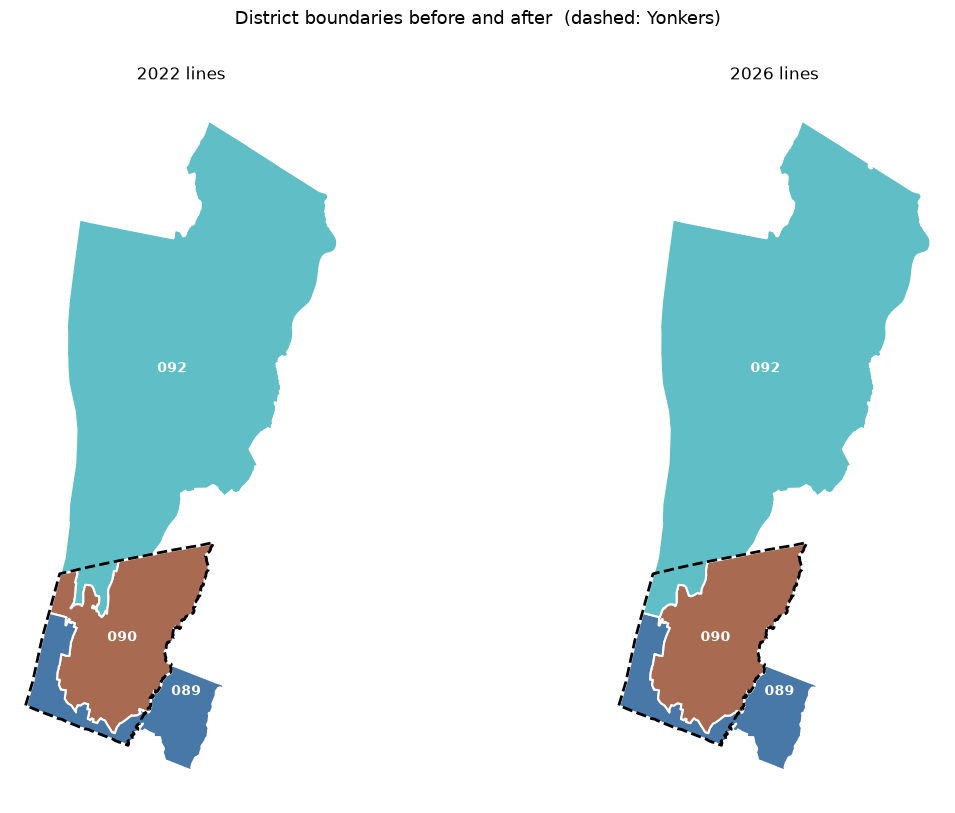

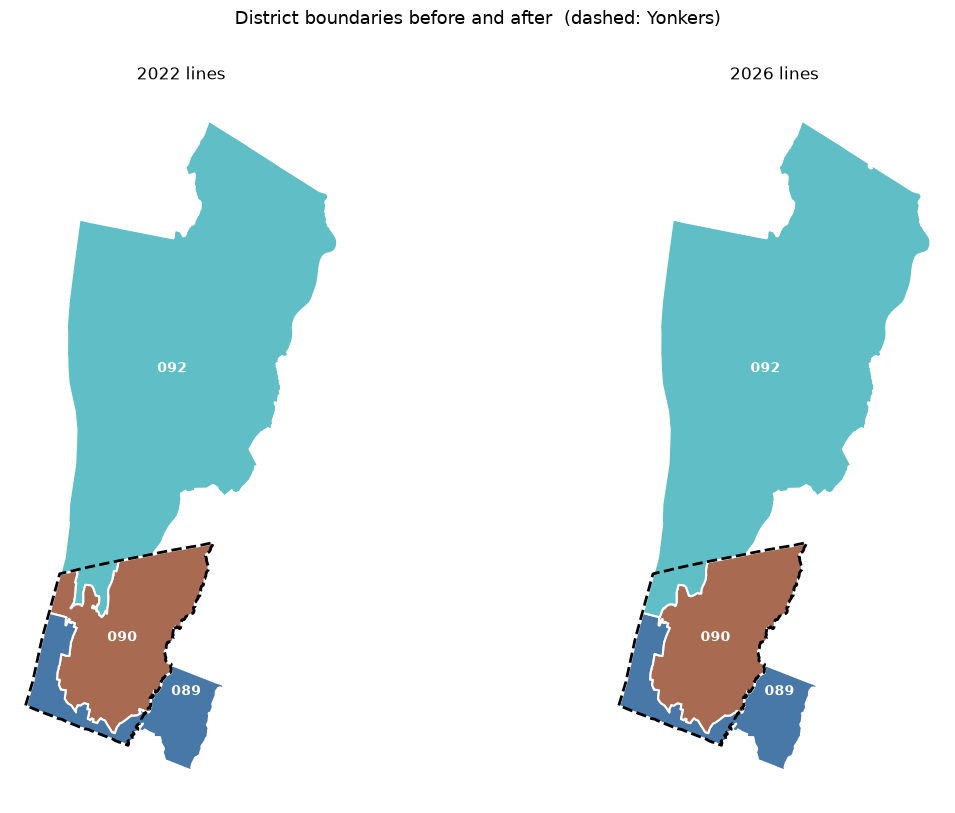

In [5]:
def get_boundary(geoid=BOUNDARY_GEOID, layer=PLACES_LAYER,
                 service="tigerWMS_Current"):
    """
    Fetch one place (city/town) outline, used as a reference line on maps.

    geoid : full place GEOID -- state FIPS + place code, e.g. "3684000" is
            Yonkers (state 36 + place 84000). Returns None if geoid is None.
    """
    if not geoid:
        return None
    g = get_layer(service, layer, where=f"GEOID='{geoid}'",
                  fields="GEOID,BASENAME,NAME")
    if g.empty:
        raise RuntimeError(f"No place found with GEOID {geoid}. "
                           f"Check the layer number for {service}.")
    name = g.iloc[0].get("BASENAME") or g.iloc[0].get("NAME")
    area = g.to_crs(AREA_CRS).area.iloc[0] / SQM_PER_SQMI
    print(f"  boundary: {name}  ({area:.1f} sq mi incl. water)")
    return g


def plot_plans(old_gdf, new_gdf, boundary=None,
               old_label=None, new_label=None,
               title="District boundaries before and after",
               boundary_label=BOUNDARY_NAME,
               save_as="district_map", figsize=None):
    """
    Side-by-side map of the two plans, on a shared extent so they compare.

    old_gdf, new_gdf : filtered plan GeoDataFrames
    boundary         : optional place GeoDataFrame drawn as a dashed line
    save_as          : PNG filename stem in OUT, or None to skip saving
    """
    old_label = old_label or OLD_PLAN["label"]
    new_label = new_label or NEW_PLAN["label"]
    figsize = figsize or (14, 8)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    xmin, ymin, xmax, ymax = pd.concat([old_gdf, new_gdf]).total_bounds
    padx, pady = (xmax - xmin) * 0.05, (ymax - ymin) * 0.05

    for ax, gdf, lab in [(axes[0], old_gdf, old_label), (axes[1], new_gdf, new_label)]:
        for _, r in gdf.iterrows():
            gpd.GeoSeries([r.geometry], crs=gdf.crs).plot(
                ax=ax, color=CMAP.get(r["SLDL"], "#999999"),
                edgecolor="white", linewidth=1.5)
            # label the largest part -- multipart centroids can fall outside
            g = r.geometry
            big = max(g.geoms, key=lambda p: p.area) if g.geom_type == "MultiPolygon" else g
            pt = big.representative_point()
            ax.annotate(r["SLDL"], (pt.x, pt.y), ha="center", va="center",
                        fontsize=10, color="white", weight="bold")
        if boundary is not None:
            boundary.boundary.plot(ax=ax, edgecolor="black",
                                   linewidth=2, linestyle="--")
        ax.set_title(lab)
        ax.axis("off")
        ax.set_xlim(xmin - padx, xmax + padx)
        ax.set_ylim(ymin - pady, ymax + pady)

    sub = f"  (dashed: {boundary_label})" if boundary is not None else ""
    fig.suptitle(title + sub, y=1.01, fontsize=13)
    plt.tight_layout()
    if save_as:
        save_fig(fig, save_as)
    plt.show() if SHOW_PLOTS else plt.close(fig)
    return fig


boundary = get_boundary()
plot_plans(o, n, boundary=boundary)


**What this does**

Draws both plans side by side, with an optional city outline.

The shared extent matters — without it each panel auto-scales to its own
contents and districts appear to grow or shrink purely from rescaling.

District colours come from `CMAP`, keyed by district number, so a district is the
same colour in both panels regardless of how many you're analysing. Labels use
`representative_point()` rather than the centroid, because a multipart district's
centre of mass can land outside every part of it.

## 6. Which counties do the districts touch?

In [6]:
def find_counties(old_gdf, new_gdf, state_fips=STATE_FIPS,
                  layer=COUNTIES_LAYER, save_as="counties_touched"):
    """
    Counties overlapping EITHER plan. Census data is requested county by county,
    so missing one silently undercounts every district.

    Both plans are used because a district may reach into a county under only
    one of them, and you need that county's data for both sides.

    Returns (county_fips_list, DataFrame) and writes the DataFrame to CSV.
    """
    counties = get_layer("tigerWMS_Current", layer, where=f"STATE='{state_fips}'",
                         fields="GEOID,BASENAME,COUNTY")

    touched = gpd.sjoin(counties, pd.concat([old_gdf, new_gdf])[["geometry"]],
                        how="inner", predicate="intersects")
    touched = touched[~touched["COUNTY"].duplicated()].sort_values("COUNTY")

    df = touched[["COUNTY", "BASENAME"]].rename(
        columns={"COUNTY": "county_fips", "BASENAME": "county_name"})

    # How much each county actually overlaps -- a hairline sliver where polygon
    # edges disagree across a river is not a real presence.
    plans = pd.concat([old_gdf, new_gdf])[["geometry"]].to_crs(AREA_CRS)
    areas = []
    for fips in df["county_fips"]:
        c = counties[counties["COUNTY"] == fips][["geometry"]].to_crs(AREA_CRS)
        ov = gpd.overlay(plans, c, how="intersection", keep_geom_type=False)
        areas.append(ov.area.sum() / SQM_PER_SQMI if len(ov) else 0.0)
    df["overlap_sqmi"] = np.round(areas, 3)

    print(df.to_string(index=False))
    fips_list = sorted(df["county_fips"])
    print(f"\nCOUNTY_FIPS = {fips_list}")
    tiny = df[df["overlap_sqmi"] < 0.01]
    if len(tiny):
        print(f"  note: {len(tiny)} county with <0.01 sq mi overlap -- likely a "
              f"boundary sliver, harmless but not a real presence.")
    save_csv(df, save_as, index=False)
    return fips_list, df


COUNTY_FIPS, counties_df = find_counties(o, n)

county_fips county_name  overlap_sqmi
        005       Bronx         0.000
        087    Rockland         0.000
        119 Westchester       181.705

COUNTY_FIPS = ['005', '087', '119']
  note: 2 county with <0.01 sq mi overlap -- likely a boundary sliver, harmless but not a real presence.
  csv  -> output\counties_touched.csv


**What this does**

Derives the county list from geographic overlap rather than hardcoding it, and
writes `counties_touched.csv`.

The overlap column is the useful addition: a county can appear because polygon
edges disagree by a few metres across a river, which is not a real presence.
Anything under 0.01 sq mi is flagged. Including such a county costs nothing —
you download blocks with nobody in them — while missing a real one would
undercount with no error.

## 7. 2020 Census block data

In [7]:
P1_VARS = {
    "P1_001N": "P1_Total(001)",   "P1_003N": "P1_White(003)",
    "P1_004N": "P1_Black(004)",   "P1_005N": "P1_AIAN(005)",
    "P1_006N": "P1_Asian(006)",   "P1_007N": "P1_NHPI(007)",
    "P1_008N": "P1_Other(008)",   "P1_009N": "P1_TwoPlus(009)",
}
P2_VARS = {
    "P2_001N": "P2_Total(001)",      "P2_002N": "P2_Hispanic(002)",
    "P2_003N": "P2_NotHispanic(003)", "P2_005N": "P2_NH_White(005)",
    "P2_006N": "P2_NH_Black(006)",   "P2_007N": "P2_NH_AIAN(007)",
    "P2_008N": "P2_NH_Asian(008)",   "P2_009N": "P2_NH_NHPI(009)",
    "P2_010N": "P2_NH_Other(010)",   "P2_011N": "P2_NH_TwoPlus(011)",
}
H1_VARS = {
    "H1_001N": "H1_TotalUnits(001)", "H1_002N": "H1_Occupied(002)",
    "H1_003N": "H1_Vacant(003)",
}
P5_VARS = {
    "P5_001N": "P5_GQTotal(001)",
    "P5_002N": "P5_Inst(002)",
    "P5_003N": "P5_Correctional(003)",
    "P5_004N": "P5_Juvenile(004)",
    "P5_005N": "P5_Nursing(005)",
    "P5_006N": "P5_OtherInst(006)",
    "P5_007N": "P5_NonInst(007)",
    "P5_008N": "P5_College(008)",
    "P5_009N": "P5_Military(009)",
    "P5_010N": "P5_OtherNonInst(010)",
}
ALL_VARS = {**P1_VARS, **P2_VARS, **H1_VARS, **P5_VARS}
#ALL_VARS = {**P1_VARS, **P2_VARS, **H1_VARS}


def census_get(dataset, variables, for_clause, in_clause, timeout=120):
    """
    One Census API request.

    The URL is hand-built rather than passed through requests' params because
    the API is literal about ':' and '*' in geography clauses -- percent-encoding
    them breaks the request. The key IS passed via params so it cannot leak
    into a traceback.
    """
    url = (f"https://api.census.gov/data/{dataset}"
           f"?get={','.join(variables)}&for={for_clause}&in={in_clause}")
    r = requests.get(url, params={"key": CENSUS_KEY}, timeout=timeout)

    # The Census API returns HTTP 200 with an HTML error page.
    if not r.text.lstrip().startswith("["):
        raise RuntimeError(f"Census API returned non-JSON:\n{r.text[:300]}")

    rows = r.json()
    return pd.DataFrame(rows[1:], columns=rows[0])


def get_block_data(county_fips, state_fips=STATE_FIPS, dataset="2020/dec/pl",
                   variables=ALL_VARS, save_as=None):
    """
    Block-level 2020 Decennial (PL 94-171) counts for the given counties.

    PL 94-171 is the redistricting file: a complete count, published at block
    level, and the data the districts were actually drawn from.

    variables : dict mapping census codes to readable column names
    Returns a DataFrame keyed by 15-digit block GEOID.
    """
    pl = pd.concat([
        census_get(dataset, list(variables), "block:*",
                   f"state:{state_fips}%20county:{f}%20tract:*")
        for f in county_fips
    ], ignore_index=True)

    # GEOID is built from TEXT, before any numeric conversion.
    pl["GEOID"] = pl["state"] + pl["county"] + pl["tract"] + pl["block"]
    for code in variables:
        pl[code] = pd.to_numeric(pl[code])
    pl = pl.rename(columns=variables)[["GEOID"] + list(variables.values())]

    assert pl["GEOID"].str.len().eq(15).all(), "malformed GEOID"
    assert not pl["GEOID"].duplicated().any(), "duplicate blocks -- county fetched twice?"

    tot = pl.get("P1_Total(001)")
    print(f"  {len(pl):,} blocks"
          + (f", {tot.sum():,} people" if tot is not None else ""))
    if save_as:
        save_csv(pl, save_as, index=False)
    return pl


def get_blocks(county_fips, state_fips=STATE_FIPS, layer=BLOCKS_LAYER):
    """Block polygons for the given counties, from TIGERweb."""
    frames = []
    for f in county_fips:
        g = get_layer("tigerWMS_Current", layer,
                      where=f"STATE='{state_fips}' AND COUNTY='{f}'",
                      fields="GEOID,STATE,COUNTY,TRACT,BLOCK")
        print(f"  county {f}: {len(g):,} block shapes")
        frames.append(g)
    blocks = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True),
                              crs="EPSG:4326")
    return blocks


def check_p5(pl):
    """P5 is nested: subtotals must equal their parts, and 002+007 = 001."""
    inst = ["P5_Correctional(003)", "P5_Juvenile(004)",
            "P5_Nursing(005)", "P5_OtherInst(006)"]
    noninst = ["P5_College(008)", "P5_Military(009)", "P5_OtherNonInst(010)"]
    gaps = {
        "institutionalized": (pl[inst].sum(axis=1) - pl["P5_Inst(002)"]).abs().max(),
        "noninstitutionalized": (pl[noninst].sum(axis=1) - pl["P5_NonInst(007)"]).abs().max(),
        "grand total": (pl["P5_Inst(002)"] + pl["P5_NonInst(007)"]
                        - pl["P5_GQTotal(001)"]).abs().max(),
    }
    for k, v in gaps.items():
        print(f"  {k:22} gap: {v:.0f}")
    assert max(gaps.values()) == 0, "P5 hierarchy does not close -- check variable codes"
    print(f"  group quarters population: {pl['P5_GQTotal(001)'].sum():,}")


pl = get_block_data(COUNTY_FIPS)
print("\nP5 hierarchy check:")
check_p5(pl)
blocks = get_blocks(COUNTY_FIPS)

  21,096 blocks, 2,815,440 people

P5 hierarchy check:
  institutionalized      gap: 0
  noninstitutionalized   gap: 0
  grand total            gap: 0
  group quarters population: 83,728
  county 005: 5,320 block shapes
  county 087: 3,718 block shapes
  county 119: 12,058 block shapes


**What this does**

Two fetches: the numbers, and the shapes.

`get_block_data()` pulls three Decennial tables. **P1** is race ignoring Hispanic
origin. **P2** separates Hispanic first, then sorts the rest by race — `P2_NH_White`
is non-Hispanic White, which is what "White" means in published reporting, so P2
is the table to chart. **H1** is housing occupancy.

The GEOID is assembled from text before numbers are converted, because it's
string concatenation, not addition. Two assertions catch malformed IDs and
duplicate blocks from a county being fetched twice.

`get_blocks()` pulls the matching polygons. Blocks are the bridge between census
data and district lines: districts are built from whole blocks, so aggregating
block counts along a district boundary is exact.

## 8. Assign blocks to districts

In [8]:
def assign_blocks(blocks_gdf, plan, colname):
    """
    Label each block with the district containing it.

    Each block is reduced to one interior point, then joined to the district
    polygons. representative_point() is used rather than centroid because a
    concave block's centre of mass can fall outside the block itself.

    Blocks in no district get NaN, which is correct -- they exist, they are just
    outside the study area.
    """
    pts = gpd.GeoDataFrame(blocks_gdf[["GEOID"]].copy(),
                           geometry=blocks_gdf.representative_point(),
                           crs=blocks_gdf.crs)
    j = gpd.sjoin(pts, plan[["SLDL", "geometry"]], how="left", predicate="within")

    dupes = int(j.index.duplicated().sum())
    if dupes:
        print(f"  WARNING: {dupes} block(s) matched MORE THAN ONE district. "
              f"The first match is kept, which is arbitrary -- investigate.")
    j = j[~j.index.duplicated()]
    return j[["GEOID", "SLDL"]].rename(columns={"SLDL": colname})


def build_study_area(blocks_gdf, pl_df, old_gdf, new_gdf):
    """
    Join counts to shapes, label both plans, keep only blocks in either plan.

    The OR is deliberate: a block in the districts under only one plan is
    exactly the kind the redraw moved, and must be kept to be accounted for.
    """
    b = blocks_gdf.merge(pl_df, on="GEOID", how="left")
    missing = b["P1_Total(001)"].isna().sum()
    if missing:
        raise RuntimeError(f"{missing} block shapes have no census data -- "
                           f"GEOID mismatch between TIGERweb and the API.")

    b = b.merge(assign_blocks(b, old_gdf, "ad_old"), on="GEOID")
    b = b.merge(assign_blocks(b, new_gdf, "ad_new"), on="GEOID")
    b = b[b["ad_old"].notna() | b["ad_new"].notna()].reset_index(drop=True)

    print(f"  blocks in study area: {len(b):,}")
    print(f"  population:           {b['P1_Total(001)'].sum():,.0f}")
    return b


def check_split_blocks(b, plan, plan_label, tol=0.995):
    """
    Do any district lines cut THROUGH a block?

    Districts are legally built from whole blocks, so this should return zero --
    but that is a claim about how the map was drawn, not something the code
    knows. If a block were genuinely split, the point-based assignment above
    would send its whole population to one side.

    Returns the count of split blocks.
    """
    bb = b[["GEOID", "geometry"]].to_crs(AREA_CRS)
    bb["area"] = bb.geometry.area

    parts = gpd.overlay(bb, plan[["SLDL", "geometry"]].to_crs(AREA_CRS),
                        how="intersection", keep_geom_type=False)
    parts = parts[parts.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    parts["share"] = parts.geometry.area / parts["area"]

    top = parts.sort_values("share", ascending=False).drop_duplicates("GEOID")
    split = int((top["share"] < tol).sum())

    print(f"  {plan_label}: {split} block(s) with <{tol:.1%} of their area "
          f"in one district")
    if split:
        bad = top[top["share"] < tol].merge(b[["GEOID", "P1_Total(001)"]], on="GEOID")
        print(f"    people affected: {bad['P1_Total(001)'].sum():,.0f}")
    return split


b = build_study_area(blocks, pl, o, n)

print("\nSplit-block check:")
split_old = check_split_blocks(b, o, OLD_PLAN["label"])
split_new = check_split_blocks(b, n, NEW_PLAN["label"])
if split_old == 0 and split_new == 0:
    print("  -> blocks nest cleanly. Point assignment is EXACT, not approximate.")

save_csv(b.drop(columns="geometry"), "blocks_assigned", index=False)
b.to_file(OUT / "blocks_assigned.gpkg", driver="GPKG")

  blocks in study area: 4,396
  population:           417,476

Split-block check:
  2022 lines: 0 block(s) with <99.5% of their area in one district
  2026 lines: 0 block(s) with <99.5% of their area in one district
  -> blocks nest cleanly. Point assignment is EXACT, not approximate.
  csv  -> output\blocks_assigned.csv


**What this does**

Builds the working dataset: every block with its 2020 counts and two district
labels, one per plan.

`assign_blocks()` warns rather than hides when a block matches more than one
district. The spatial join emits one row per match, and keeping the first is
arbitrary — silently dropping those would mean an unrecorded coin flip.

`check_split_blocks()` answers the question that decides whether any of this is
valid: does a district line ever cut through a block? It measures what share of
each block's area falls in each district. Zero split blocks means the
point-based assignment is exact, with no population misassigned. It runs against
both plans, since they have different boundaries.

## 9. Which blocks changed district?

blocks changed: 35
people:         2,500 (0.60% of study population)

                    blocks  people
type                              
between districts       29    2487
entered study area       1      10
left study area          5       3
  csv  -> output\blocks_changed_summary.csv

Population moved (rows = old district, cols = new):

ad_new   090  092
ad_old           
089      255    0
090        0  541
092     1691    0
  csv  -> output\blocks_changed_flow.csv

          pop_old  pop_new  change  explained  gap
district                                          
089        140205   139950    -255       -255    0
090        137768   139173    1405       1405    0
092        139493   138350   -1143      -1143    0
  csv  -> output\reconciliation.csv

  PASS -- every person traces to a specific block
  png  -> output\changed_blocks_map.png


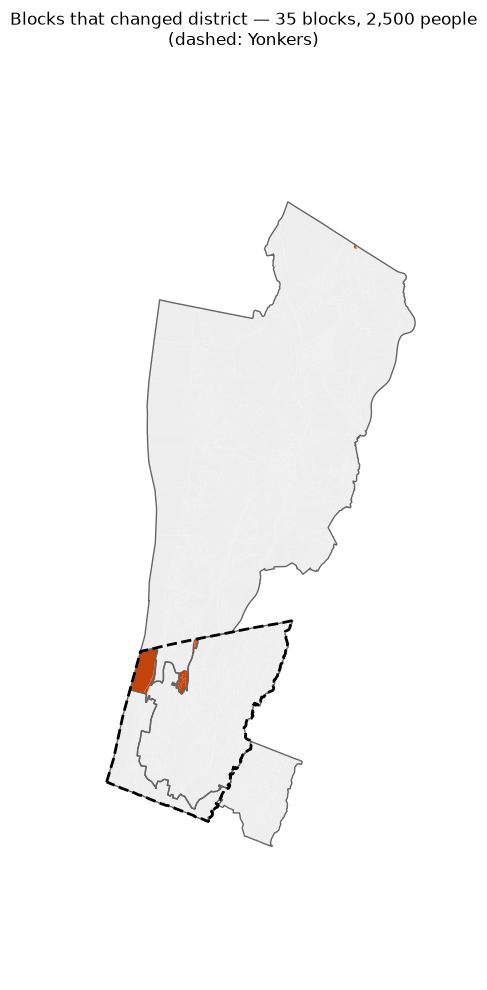

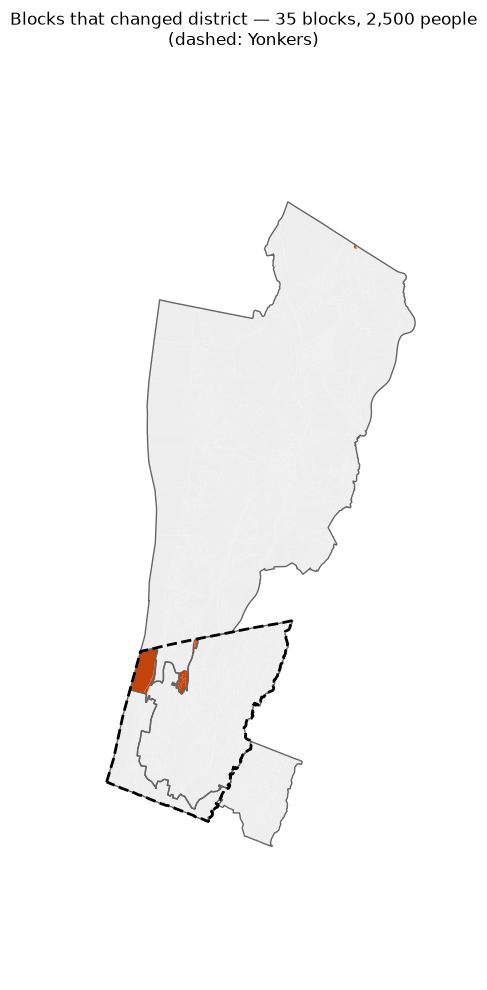

In [9]:
def find_changed(b, pop_col="P1_Total(001)", save_as="blocks_changed"):
    """
    Blocks whose district label differs between plans.

    NaN never equals anything, so `!=` catches all three cases at once:
    moved between districts, left the study area, entered from outside.
    Returns the changed-block GeoDataFrame and writes a summary CSV.
    """
    moved = b[b["ad_old"] != b["ad_new"]].copy()
    moved["type"] = "between districts"
    moved.loc[moved["ad_new"].isna(), "type"] = "left study area"
    moved.loc[moved["ad_old"].isna(), "type"] = "entered study area"

    total = b[pop_col].sum()
    print(f"blocks changed: {len(moved):,}")
    print(f"people:         {moved[pop_col].sum():,.0f} "
          f"({moved[pop_col].sum() / total:.2%} of study population)\n")

    summary = moved.groupby("type").agg(
        blocks=("GEOID", "size"), people=(pop_col, "sum"))
    print(summary.to_string())
    save_csv(summary, f"{save_as}_summary")

    inside = moved[moved["type"] == "between districts"]
    if len(inside):
        flow = inside.pivot_table(index="ad_old", columns="ad_new",
                                  values=pop_col, aggfunc="sum", fill_value=0)
        print("\nPopulation moved (rows = old district, cols = new):\n")
        print(flow.to_string())
        save_csv(flow, f"{save_as}_flow")
    return moved


def reconcile(b, moved, pop_col="P1_Total(001)", save_as="reconciliation"):
    """
    Every person a district gained or lost must trace to a block that moved.

    This is the check that catches silently dropped blocks -- the gap column
    must be all zeros.
    """
    rows = {}
    for d in sorted(set(b["ad_old"].dropna()) | set(b["ad_new"].dropna())):
        old_pop = b.loc[b["ad_old"] == d, pop_col].sum()
        new_pop = b.loc[b["ad_new"] == d, pop_col].sum()
        gained = moved.loc[moved["ad_new"] == d, pop_col].sum()
        lost = moved.loc[moved["ad_old"] == d, pop_col].sum()
        rows[d] = {"pop_old": old_pop, "pop_new": new_pop,
                   "change": new_pop - old_pop, "explained": gained - lost}

    rec = pd.DataFrame(rows).T
    rec["gap"] = rec["change"] - rec["explained"]
    rec.index.name = "district"
    print(rec.to_string())
    save_csv(rec, save_as)

    assert rec["gap"].abs().max() == 0, \
        "movement does not explain the change column -- do not publish"
    print("\n  PASS -- every person traces to a specific block")
    return rec


def plot_changed(b, moved, old_gdf, boundary=None, zoom=True,
                 title=None, boundary_label=BOUNDARY_NAME,
                 pop_col="P1_Total(001)", save_as="changed_blocks_map",
                 figsize=(9, 10)):
    """
    Map the blocks that changed district.

    boundary : optional place outline, drawn dashed
    zoom     : frame on the changed blocks (they are usually a tiny share
               of the area and invisible at full extent)
    """
    fig, ax = plt.subplots(figsize=figsize)
    b.plot(ax=ax, color="#eeeeee", edgecolor="none")
    if len(moved):
        moved.plot(ax=ax, color=NEG_COLOR, edgecolor="none")
    old_gdf.boundary.plot(ax=ax, edgecolor="#666666", linewidth=1)
    if boundary is not None:
        boundary.boundary.plot(ax=ax, edgecolor="black",
                               linewidth=2, linestyle="--")

    if zoom and len(moved):
        xmin, ymin, xmax, ymax = moved.total_bounds
        mx, my = (xmax - xmin) * 0.35 + 1e-4, (ymax - ymin) * 0.35 + 1e-4
        ax.set_xlim(xmin - mx, xmax + mx)
        ax.set_ylim(ymin - my, ymax + my)

    if title is None:
        title = (f"Blocks that changed district — {len(moved)} blocks, "
                 f"{moved[pop_col].sum():,.0f} people")
    if boundary is not None:
        title += f"\n(dashed: {boundary_label})"
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    if save_as:
        save_fig(fig, save_as)
    plt.show() if SHOW_PLOTS else plt.close(fig)
    return fig


moved = find_changed(b)
print()
reconcile(b, moved)
plot_changed(b, moved, o, boundary=boundary)

**What this does**

Finds the blocks the redraw moved, proves the arithmetic closes, and maps them.

`find_changed()` produces the flow table — rows are the losing district, columns
the gaining one. Each off-diagonal cell is a specific neighbourhood that changed
representation, which is usually the most publishable table in this kind of work.

`reconcile()` is the safeguard. It rebuilds each district's change from the
individual block movements and asserts they match. Blocks that leave the study
area entirely still shrink their old district, so omitting them makes the change
column unexplainable — the assertion stops that reaching a chart.

`plot_changed()` zooms to the changed blocks by default, since they are typically
under 1% of the area and invisible otherwise.

## 10. Datawrapper export

In [10]:
DW_CHARTS = []          # registry of every chart pushed, exported at the end


def to_datawrapper(df, title, label_column=None, intro="", notes="",
                   source_name=DW_SOURCE, byline=DW_BYLINE,
                   value_format="0,0.[00]", publish=None, skip=False):
    """
    Push one table to Datawrapper as a SINGLE-SERIES bar chart.

    Requires `pip install datawrapper` and DATAWRAPPER_ACCESS_TOKEN in .env.

    NOTE: dw.BarChart draws one bar_column and silently ignores the rest, so
    this is only right for a one-column table. For before/after tables use
    to_datawrapper_grouped() below.

    PARAMETERS
        df           : DataFrame. The index (or label_column) becomes the bar
                       labels.
        title        : chart headline.
        label_column : column holding the bar labels; None uses the index.
        intro        : text above the chart.
        notes        : footnote below the chart.
        value_format : Datawrapper number format -- "0,0" integers,
                       "0.00%" percentages, "0.00" plain decimals.
        publish      : override DW_PUBLISH for this one chart.
        skip         : caller-side switch to suppress this chart only.

    RETURNS
        The chart object, or None if disabled, skipped, or the push failed.

    Failures are caught and reported rather than raised: a bad token should not
    kill a run that has already fetched thousands of blocks, and the PNG and
    CSV are written regardless.
    """
    if not DW_ENABLED or skip:
        return None

    publish = DW_PUBLISH if publish is None else publish
    try:
        import datawrapper as dw

        data = df.reset_index() if label_column is None else df.copy()
        label_column = label_column or data.columns[0]

        # Datawrapper type-detects each column on upload. A label column of
        # "089", "090", "092" reads as integers however pandas types it, so
        # Datawrapper charts the district numbers as if they were data.
        # Prefixing forces it to text.
        data[label_column] = data[label_column].astype(str)
        if data[label_column].str.fullmatch(r"\d+").all():
            data[label_column] = "AD " + data[label_column]

        # Label column first, everything after it numeric.
        value_cols = [c for c in data.columns if c != label_column]
        data = data[[label_column] + value_cols]
        for c in value_cols:
            data[c] = pd.to_numeric(data[c], errors="coerce")

        chart = dw.BarChart(
            title=title, intro=intro, notes=notes,
            source_name=source_name, byline=byline,
            data=data, label_column=label_column,
            show_value_labels=True, value_label_format=value_format,
            sort_bars=False, show_color_key=True,
            access_token=DW_TOKEN or None,
        )
        chart.create()
        url = f"https://app.datawrapper.de/chart/{chart.chart_id}/visualize"
        print(f"  dw   -> {url}")
        if publish:
            chart.publish()
        DW_CHARTS.append({"title": title, "chart_id": chart.chart_id,
                          "url": url, "published": publish})
        return chart

    except Exception as e:
        print(f"  dw   -> FAILED ({type(e).__name__}: {e})")
        return None


def to_datawrapper_grouped(df, title, intro="", notes="",
                           value_format="0,0", publish=None, skip=False):
    """
    Push one table to Datawrapper as a GROUPED bar chart.

    One group per row, one bar per numeric column -- so a before/after table
    renders as paired bars, matching the matplotlib version.

    Uses the d3-bars-grouped chart type via the lower-level client, because
    the typed BarChart class does not expose it.

    PARAMETERS
        df           : DataFrame indexed by district. The first column after
                       reset_index becomes the group label; every other column
                       becomes a bar within each group.
        title        : chart headline.
        intro        : text above the chart.
        notes        : footnote below the chart.
        value_format : Datawrapper number format -- "0,0" integers,
                       "0.00%" percentages, "0.00" plain decimals.
        publish      : override DW_PUBLISH for this one chart.
        skip         : caller-side switch to suppress this chart only.

    RETURNS
        The chart id, or None if disabled, skipped, or the push failed.
    """
    if not DW_ENABLED or skip:
        return None

    publish = DW_PUBLISH if publish is None else publish
    try:
        from datawrapper import Datawrapper
        dwc = Datawrapper(access_token=DW_TOKEN)

        data = df.reset_index()
        label_col = data.columns[0]

        data[label_col] = data[label_col].astype(str)
        if data[label_col].str.fullmatch(r"\d+").all():
            data[label_col] = "AD " + data[label_col]
        for c in data.columns[1:]:
            data[c] = pd.to_numeric(data[c], errors="coerce")

        meta = {
            "describe": {"intro": intro, "notes": notes,
                         "source-name": DW_SOURCE, "byline": DW_BYLINE},
            "visualize": {"show-value-labels": True,
                          "value-label-format": value_format},
        }

        # create_chart accepts data and metadata directly -- one call, not three.
        chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",
                                 data=data, metadata=meta)
        cid = chart["id"] if isinstance(chart, dict) else chart

        url = f"https://app.datawrapper.de/chart/{cid}/visualize"
        print(f"  dw   -> {url}  (grouped, {len(data.columns) - 1} series)")
        if publish:
            dwc.publish_chart(cid)
        DW_CHARTS.append({"title": title, "chart_id": cid,
                          "url": url, "published": publish})
        return cid

    except Exception as e:
        print(f"  dw   -> GROUPED FAILED ({type(e).__name__}: {e})")
        return None


if DW_ENABLED:
    try:
        import datawrapper
        print("Datawrapper: ON -- charts created as "
              + ("published" if DW_PUBLISH else "drafts"))
    except ImportError:
        print("Datawrapper: ON but the package is missing. "
              "Run `pip install datawrapper`; charts will be skipped.")
else:
    print("Datawrapper: OFF (set DW_ENABLED = True in the config cell)")

Datawrapper: ON -- charts created as drafts


**What this does**

Pushes any table to Datawrapper as a bar chart. Defined **before** the chart
functions, because each of them calls it.

The index becomes the bar labels and each numeric column becomes a series, so a
before/after table renders as grouped bars automatically.

Two things worth noting. Failures are caught rather than raised — a bad token or
a network blip would otherwise destroy a run that already fetched thousands of
blocks, and the PNG and CSV are saved either way. And `DW_CHARTS` records every
chart created, so the last cell can write an index of titles and URLs.

`chart.create()` makes a draft you can edit in the Datawrapper UI. Set
`DW_PUBLISH = True` to publish immediately instead.

## 11. Chart functions

In [11]:
def summarise(b, value_cols, labels=None, old_col="ad_old", new_col="ad_new"):
    """
    Totals per district under both plans, plus change and percent change.

    value_cols : list of block-level columns to sum, or dict {column: label}
    Returns (old_df, new_df, change_df, pct_df) all indexed by district.
    """
    if isinstance(value_cols, dict):
        labels, value_cols = list(value_cols.values()), list(value_cols.keys())
    labels = labels or value_cols

    districts = sorted(set(b[old_col].dropna()) | set(b[new_col].dropna()))
    old = b.groupby(old_col)[value_cols].sum().reindex(districts).fillna(0)
    new = b.groupby(new_col)[value_cols].sum().reindex(districts).fillna(0)
    old.columns = new.columns = labels
    old.index.name = new.index.name = "district"

    chg = new - old
    pct = (chg / old.replace(0, np.nan) * 100)
    return old, new, chg, pct


def chart_levels(old, new, title, ylabel, save_as,
                 old_label=None, new_label=None, value_fmt="{:,.0f}",
                 figsize=None, label_rotation=0, max_labelled_bars=24,
                 dw_skip=False):
    """
    Grouped bars: each value under both plans.

    One measure   -> a single panel, districts across the x axis.
    Many measures -> one panel per district, measures across the x axis.

    Writes the table to CSV, pushes a grouped bar chart to Datawrapper,
    then draws the PNG.
    """
    old_label = old_label or OLD_PLAN["label"]
    new_label = new_label or NEW_PLAN["label"]
    measures, districts = list(old.columns), list(old.index)

    tidy = old.join(new, lsuffix=f" ({old_label})", rsuffix=f" ({new_label})")
    save_csv(tidy.round(2), save_as)
    to_datawrapper_grouped(tidy.round(2), title,
                           intro=f"{ylabel}. Bars show both plans.",
                           value_format="0,0", skip=dw_skip)

    w = 0.38
    if len(measures) == 1:
        fig, ax = plt.subplots(figsize=figsize or (max(7, 1.4 * len(districts) + 3), 5))
        xs = np.arange(len(districts))
        r1 = ax.bar(xs - w/2, old[measures[0]], w, label=old_label, color=OLD_COLOR)
        r2 = ax.bar(xs + w/2, new[measures[0]], w, label=new_label, color=NEW_COLOR)
        if 2 * len(districts) <= max_labelled_bars:
            ax.bar_label(r1, fmt=value_fmt, fontsize=8, padding=2, rotation=90)
            ax.bar_label(r2, fmt=value_fmt, fontsize=8, padding=2, rotation=90)
        ax.set_xticks(xs)
        ax.set_xticklabels([str(d) for d in districts], rotation=label_rotation)
        ax.set_ylabel(ylabel)
        ax.legend(frameon=False, fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        ax.margins(y=0.25)
    else:
        ncol = len(districts)
        fig, axes = plt.subplots(1, ncol, sharey=True,
                                 figsize=figsize or (min(4.6 * ncol, 26), 5))
        axes = np.atleast_1d(axes)
        xs = np.arange(len(measures))
        for ax, d in zip(axes, districts):
            r1 = ax.bar(xs - w/2, old.loc[d], w, label=old_label, color=OLD_COLOR)
            r2 = ax.bar(xs + w/2, new.loc[d], w, label=new_label, color=NEW_COLOR)
            if 2 * len(measures) <= max_labelled_bars:
                ax.bar_label(r1, fmt=value_fmt, fontsize=7, padding=2, rotation=90)
                ax.bar_label(r2, fmt=value_fmt, fontsize=7, padding=2, rotation=90)
            ax.set_xticks(xs)
            ax.set_xticklabels(measures, rotation=label_rotation or 35,
                               ha="right", fontsize=8)
            ax.set_title(str(d), fontsize=10)
            ax.spines[["top", "right"]].set_visible(False)
            ax.margins(y=0.25)
        axes[0].set_ylabel(ylabel)
        axes[0].legend(frameon=False, fontsize=9)

    fig.suptitle(title, y=1.02, fontsize=12)
    plt.tight_layout()
    save_fig(fig, save_as)
    plt.show() if SHOW_PLOTS else plt.close(fig)
    return tidy


def chart_change(chg, pct, title, save_as, unit="people",
                 figsize=(13, None), measure=None, dw_skip=False):
    """
    Two panels per measure: absolute change and percent change.

    chg, pct : DataFrames indexed by district, one column per measure
    measure  : name of a single column to chart, or None for all columns
    """
    measures = [measure] if measure else list(chg.columns)
    out = chg.add_suffix(" change").join(pct.add_suffix(" pct")).round(3)
    save_csv(out, save_as)
    to_datawrapper_grouped(chg.round(2), f"{title} \u2014 absolute",
                           intro=f"Change in {unit} attributable to the boundary change.",
                           value_format="0,0", skip=dw_skip)
    to_datawrapper_grouped(pct.round(2), f"{title} \u2014 percent",
                           intro="Percent change attributable to the boundary change.",
                           value_format="0.00%", skip=dw_skip)

    for m in measures:
        h = max(3.2, 0.55 * len(chg) + 1.8)
        fig, axes = plt.subplots(1, 2, figsize=(figsize[0], h))
        labels = [str(i) for i in chg.index]

        for ax, series, fmt, xlab, sub in [
            (axes[0], chg[m], "{:+,.0f}", f"Change in {unit}", "Absolute change"),
            (axes[1], pct[m], "{:+.2f}%", "Change (%)", "Percent change"),
        ]:
            c = [NEG_COLOR if (v < 0) else POS_COLOR for v in series.fillna(0)]
            r = ax.barh(labels, series.fillna(0), color=c, height=0.6)
            ax.bar_label(r, fmt=fmt, fontsize=9, padding=4)
            ax.axvline(0, color="#333333", linewidth=1.2)
            ax.set_xlabel(xlab); ax.set_title(sub)
            ax.spines[["top", "right", "left"]].set_visible(False)
            ax.tick_params(left=False); ax.margins(x=0.32)

        fig.suptitle(f"{title} — {m}" if len(measures) > 1 else title, y=1.04)
        plt.tight_layout()
        save_fig(fig, f"{save_as}_{m}".replace(" ", "_").replace("/", "-")
                 if len(measures) > 1 else save_as)
        plt.show() if SHOW_PLOTS else plt.close(fig)
    return out


def chart_shares(old, new, title, save_as, figsize=None,
                 max_labelled_bars=40, dw_skip=False):
    """
    Each measure as a share of the district total, and the change in
    PERCENTAGE POINTS -- not percent. A district going 42.0% to 41.7%
    changed by 0.3 points; calling that 0.3 percent is wrong.

    Width grows with the number of districts; height stays fixed.
    """
    sh_old = old.div(old.sum(axis=1), axis=0) * 100
    sh_new = new.div(new.sum(axis=1), axis=0) * 100
    pp = sh_new - sh_old

    out = sh_old.add_suffix(" % old").join(sh_new.add_suffix(" % new")) \
                .join(pp.add_suffix(" pp change")).round(2)
    print(out.to_string())
    save_csv(out, save_as)
    to_datawrapper_grouped(pp.round(2), title,
                           intro="Change in share, in PERCENTAGE POINTS (not percent).",
                           notes="A district going from 42.0% to 41.7% changed by "
                                 "0.3 percentage points, not 0.3 percent.",
                           value_format="0.00", skip=dw_skip)

    width = figsize[0] if figsize else min(9 + 1.3 * len(pp.index), 28)
    fig, ax = plt.subplots(figsize=(width, 5.5))
    xs = np.arange(len(pp.index)); w = 0.8 / len(pp.columns)
    cmap = plt.get_cmap("tab10")
    label_them = len(pp.index) * len(pp.columns) <= max_labelled_bars
    for k, col in enumerate(pp.columns):
        r = ax.bar(xs + (k - (len(pp.columns) - 1) / 2) * w, pp[col], w,
                   label=col, color=cmap(k % 10))
        if label_them:
            ax.bar_label(r, fmt="{:+.2f}", fontsize=7, padding=2, rotation=90)
    ax.axhline(0, color="#333333", linewidth=1.1)
    ax.set_xticks(xs); ax.set_xticklabels([str(i) for i in pp.index])
    ax.set_ylabel("Change in share (percentage points)")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8, ncol=min(len(pp.columns), 5))
    ax.spines[["top", "right"]].set_visible(False); ax.margins(y=0.3)
    plt.tight_layout()
    save_fig(fig, save_as)
    plt.show() if SHOW_PLOTS else plt.close(fig)
    return out

**What this does**

Four generic functions that every analysis below reuses. None of them hardcode a
measure or a number of districts.

- **`summarise()`** — totals per district under both plans, plus change and
  percent change. Takes any list of block-level columns.
- **`chart_levels()`** — grouped bars, both plans side by side.
- **`chart_change()`** — absolute and percent change, two panels.
- **`chart_shares()`** — composition as shares, with change in **percentage
  points**. That distinction matters: a district going from 42.0% to 41.7%
  Hispanic changed by 0.3 points, not 0.3 percent, and conflating them is the
  most common error in this kind of reporting.

Every one writes its table to CSV next to the PNG **and** pushes it to
Datawrapper when `DW_ENABLED` is on, so each measure exists in three forms: a
data file, a static image, and an editable online chart.

Each takes a `dw_skip` flag so a caller can suppress the Datawrapper push for
charts that exist only for cross-checking — used below for the P1 race charts.

## 12. Run the analyses

In [12]:
from pathlib import Path
print("cwd:", Path.cwd())
print(".env here?", (Path.cwd() / ".env").exists())
print(".env parent?", (Path.cwd().parent / ".env").exists())

cwd: c:\Users\Atharv\Projects\Redistricting_Auto_BranchFour
.env here? True
.env parent? False



POPULATION
          Population old  Population new
district                                
089               140205          139950
090               137768          139173
092               139493          138350
  csv  -> output\all_population.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/jEtrR/visualize  (grouped, 2 series)
  png  -> output\all_population.png


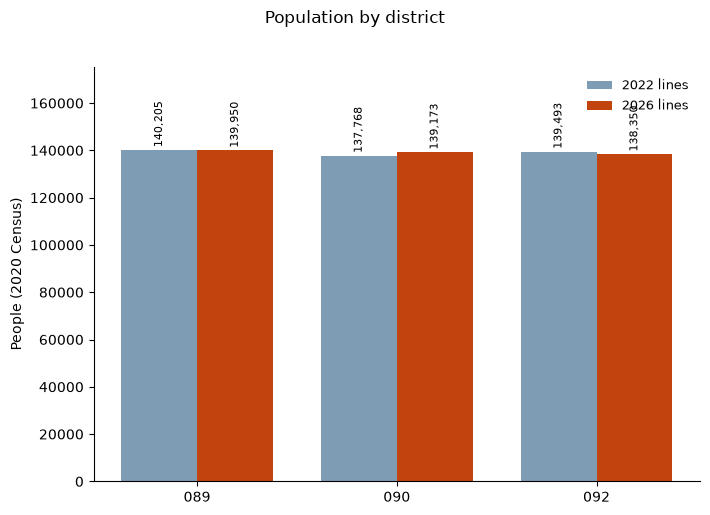

  csv  -> output\all_population_change.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/WSfms/visualize  (grouped, 1 series)


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/l44zk/visualize  (grouped, 1 series)
  png  -> output\all_population_change.png


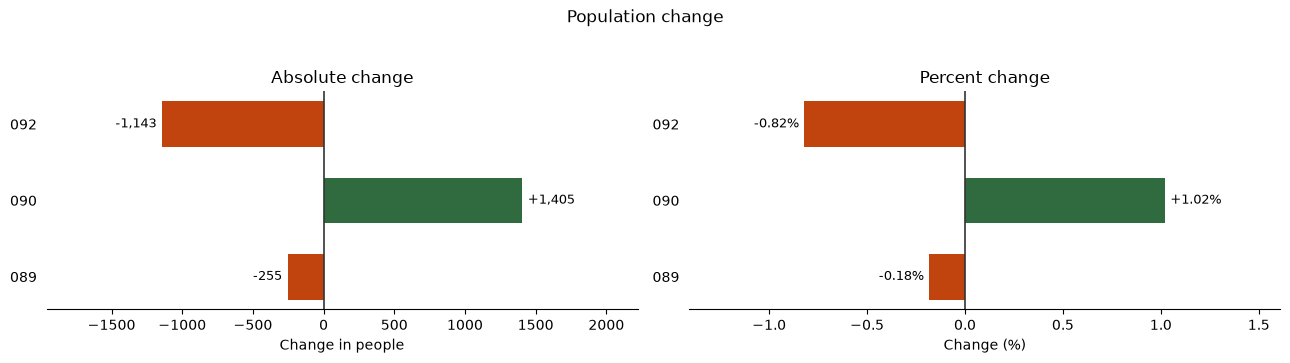


RACE — P2 (Hispanic separated)
          Hispanic  NH White  NH Black  NH AIAN  NH Asian  NH NHPI  NH Other  NH Two+
district                                                                             
089          46523     23255     59082      267      4297       35      2089     4657
090          54165     51427     18122      192      9499       18      1140     3205
092          27902     81454     12233      117     12089       12       991     4695
  csv  -> output\all_race_p2.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/zRBwC/visualize  (grouped, 16 series)
  png  -> output\all_race_p2.png


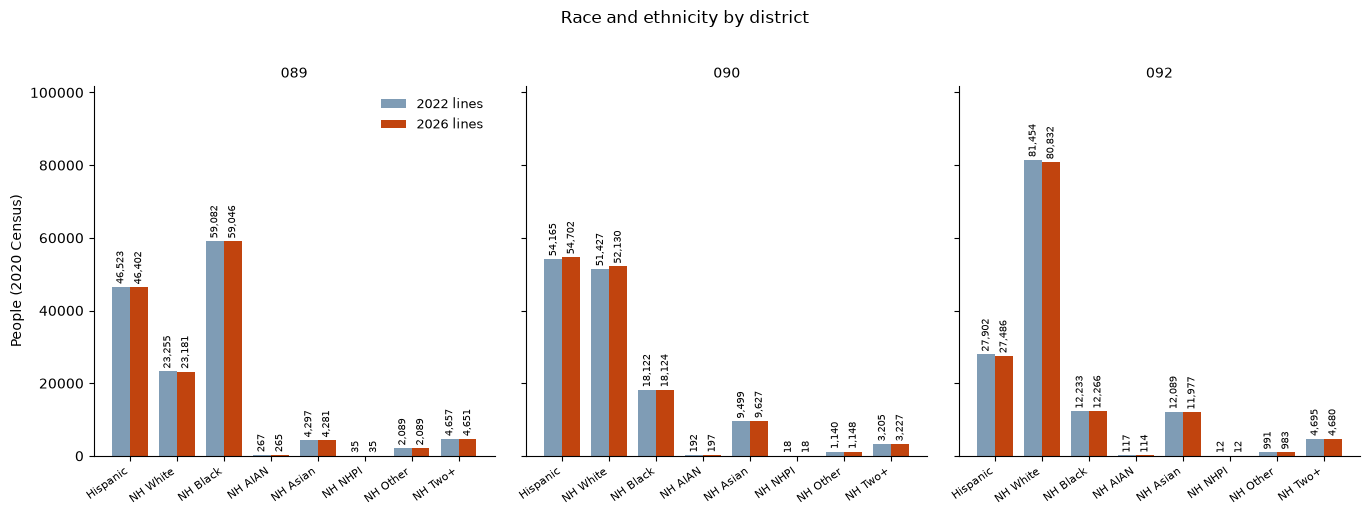

  csv  -> output\all_race_p2_change.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/gZQYZ/visualize  (grouped, 8 series)


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/hdT5x/visualize  (grouped, 8 series)
  png  -> output\all_race_p2_change_Hispanic.png


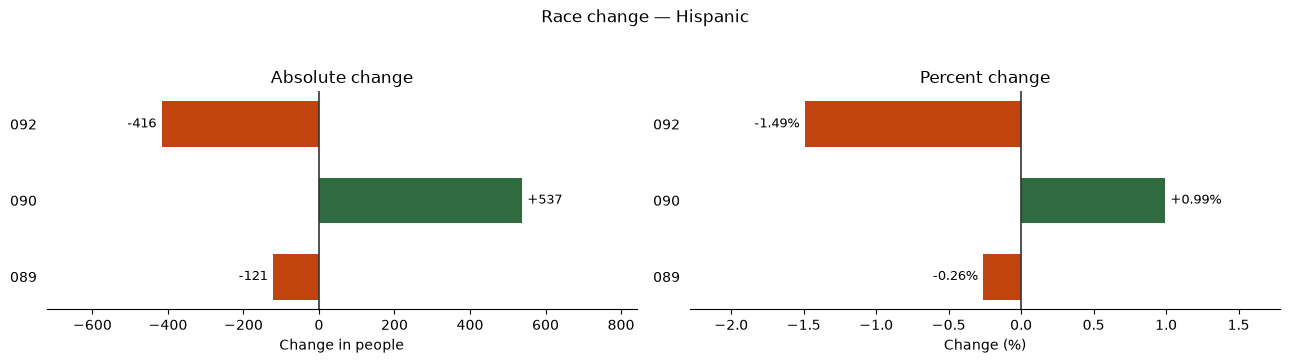

  png  -> output\all_race_p2_change_NH_White.png


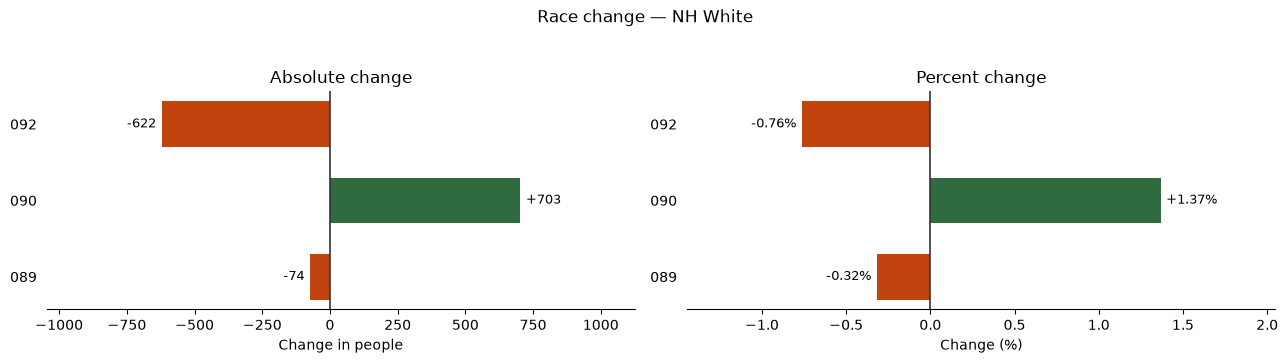

  png  -> output\all_race_p2_change_NH_Black.png


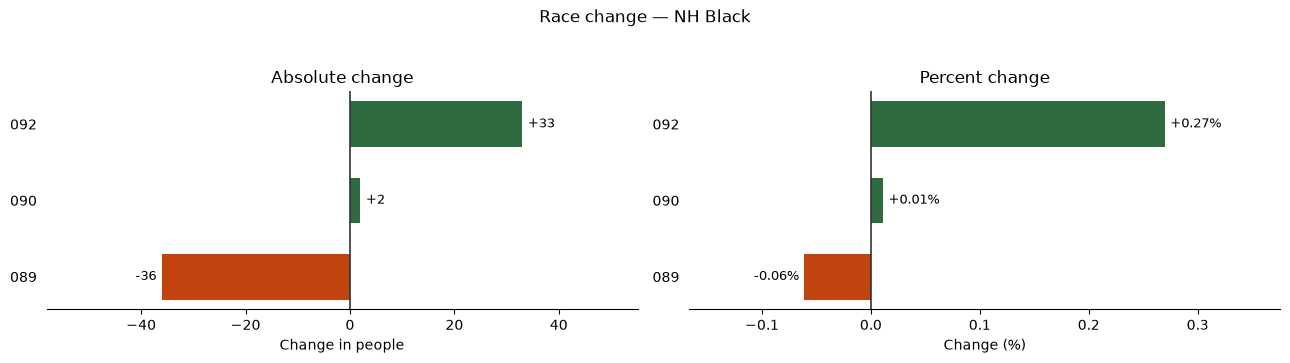

  png  -> output\all_race_p2_change_NH_AIAN.png


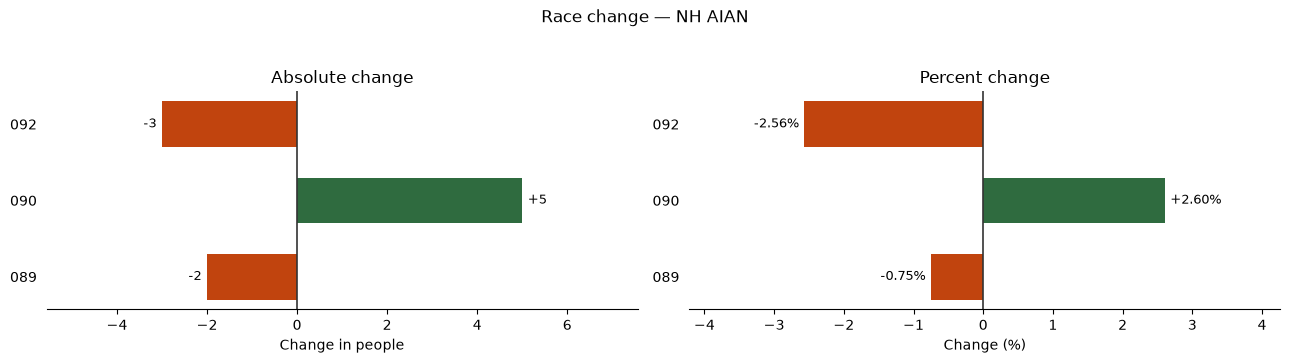

  png  -> output\all_race_p2_change_NH_Asian.png


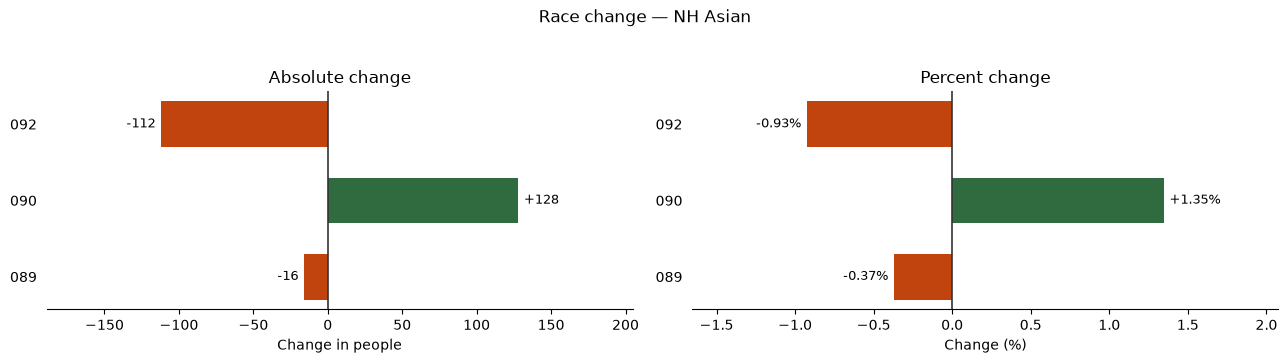

  png  -> output\all_race_p2_change_NH_NHPI.png


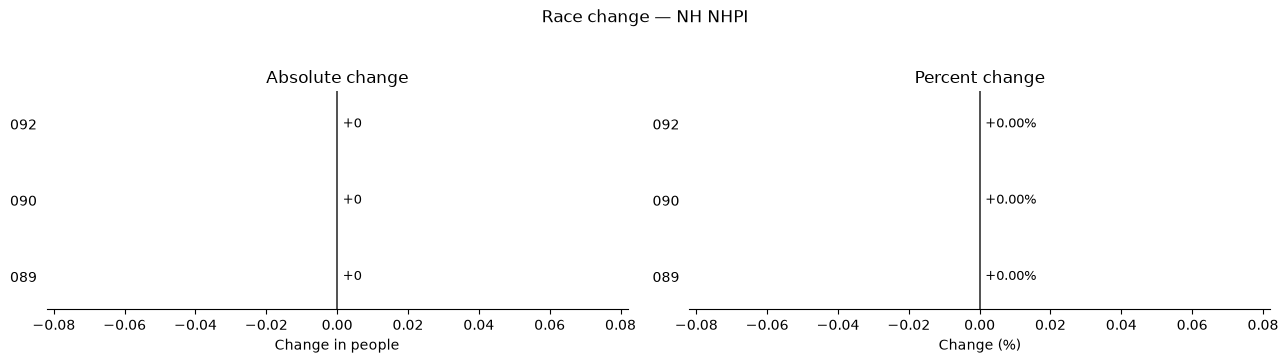

  png  -> output\all_race_p2_change_NH_Other.png


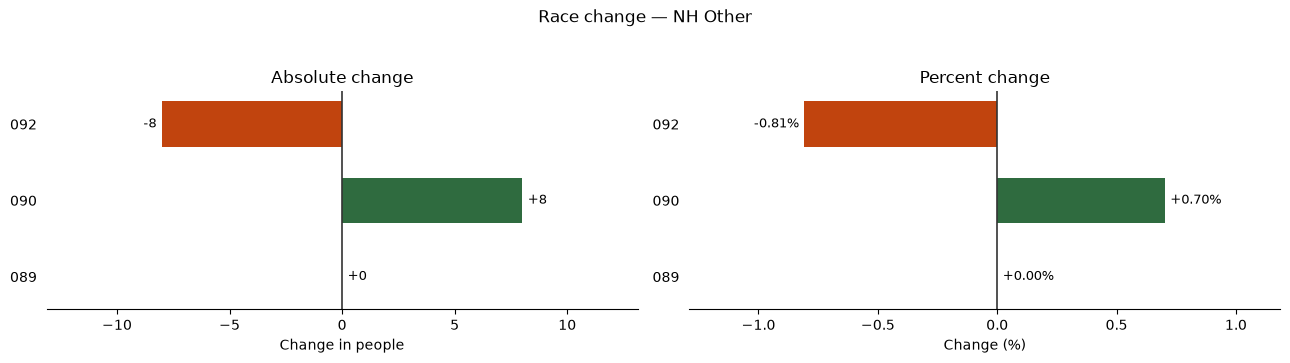

  png  -> output\all_race_p2_change_NH_Two+.png


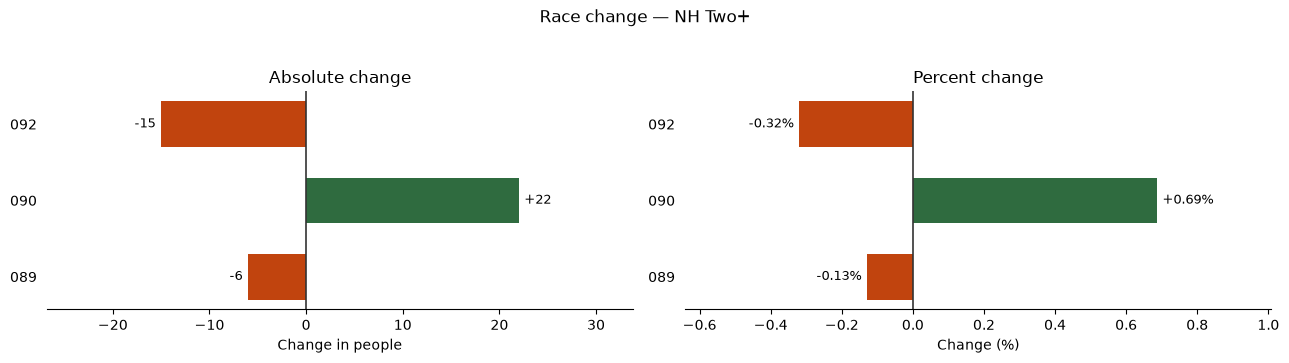

          Hispanic % old  NH White % old  NH Black % old  NH AIAN % old  NH Asian % old  NH NHPI % old  NH Other % old  NH Two+ % old  Hispanic % new  NH White % new  NH Black % new  NH AIAN % new  NH Asian % new  NH NHPI % new  NH Other % new  NH Two+ % new  Hispanic pp change  NH White pp change  NH Black pp change  NH AIAN pp change  NH Asian pp change  NH NHPI pp change  NH Other pp change  NH Two+ pp change
district                                                                                                                                                                                                                                                                                                                                                                                                                       
089                33.18           16.59           42.14           0.19            3.06           0.02            1.49           3.32           33.16           16.56   

C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/ftKod/visualize  (grouped, 8 series)
  png  -> output\all_race_p2_shares.png


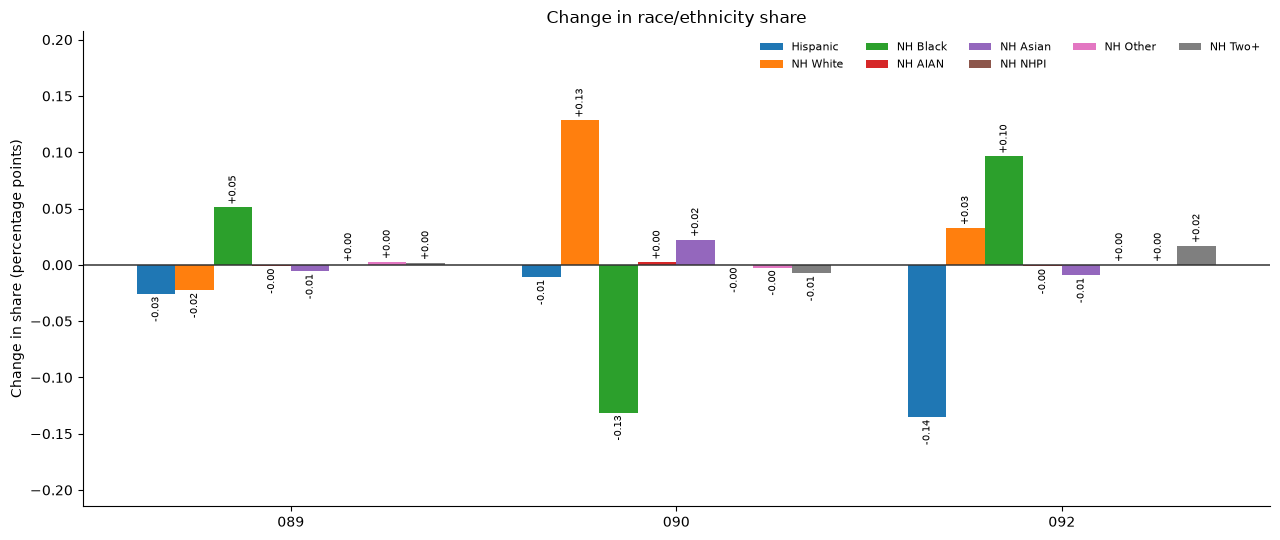


RACE — P1 (race only, Hispanic not separated)
          White  Black  AIAN  Asian  NHPI  Other   Two+
district                                               
089       27728  62469  1428   4420    79  27973  16108
090       57791  20695  1559   9666    48  31224  16785
092       85478  13134   592  12214    23  13541  14511
  csv  -> output\all_race_p1.csv
  png  -> output\all_race_p1.png


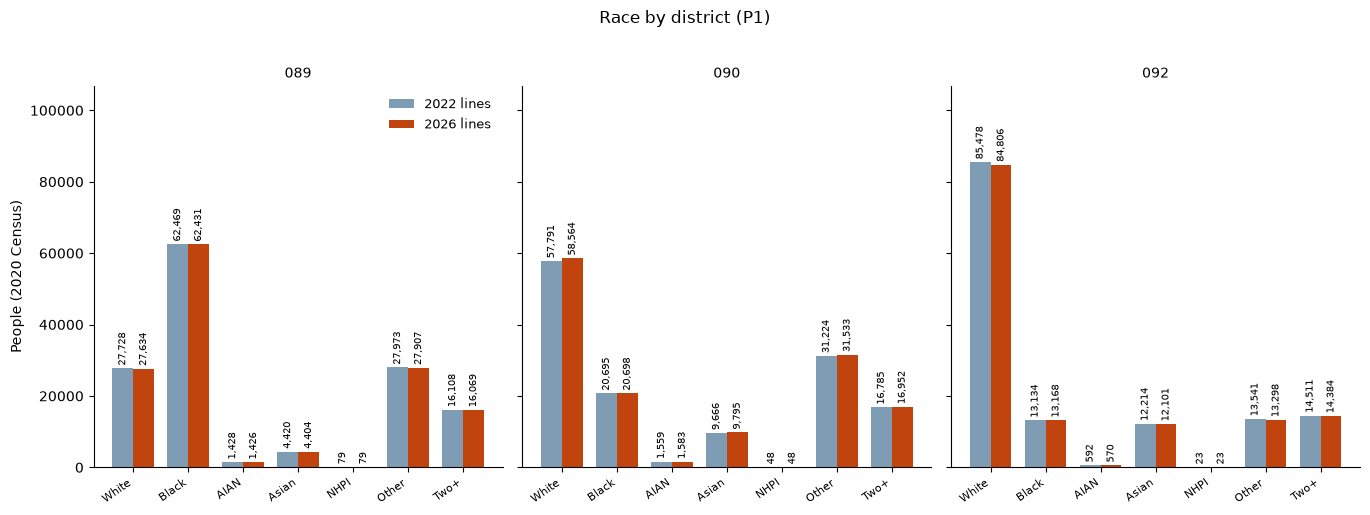

  csv  -> output\all_race_p1_change.csv
  png  -> output\all_race_p1_change_White.png


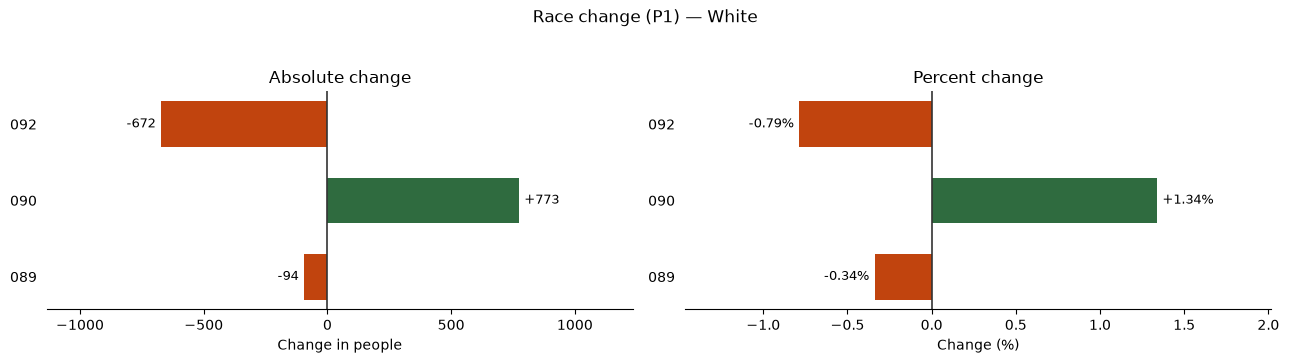

  png  -> output\all_race_p1_change_Black.png


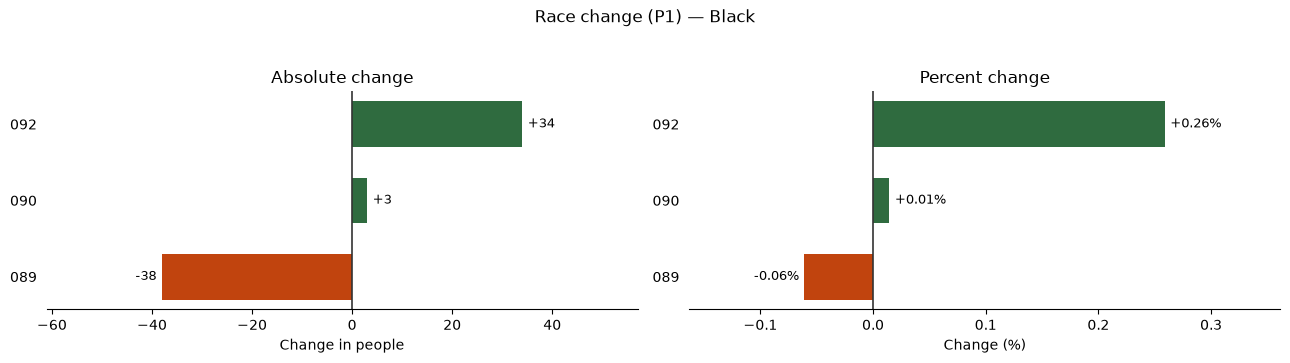

  png  -> output\all_race_p1_change_AIAN.png


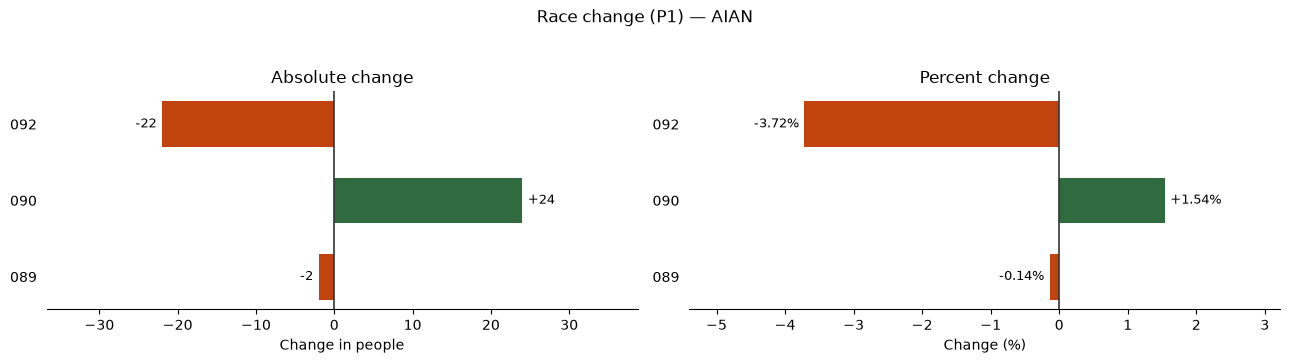

  png  -> output\all_race_p1_change_Asian.png


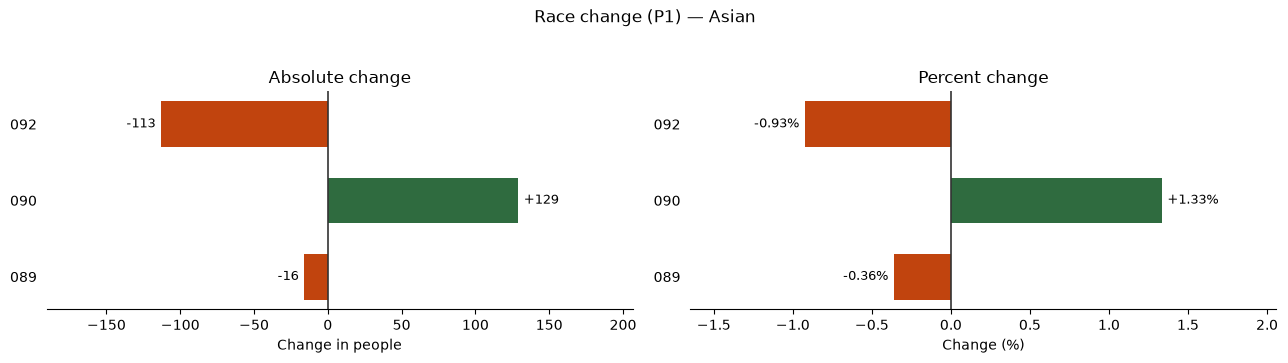

  png  -> output\all_race_p1_change_NHPI.png


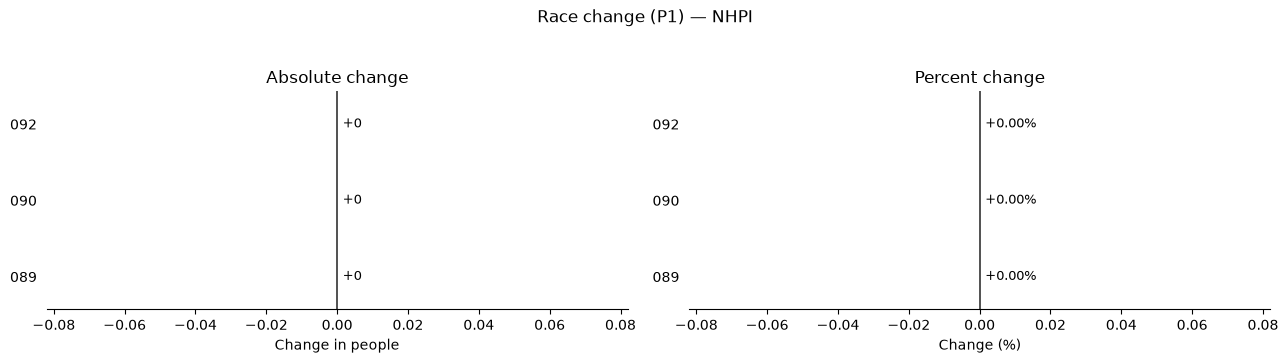

  png  -> output\all_race_p1_change_Other.png


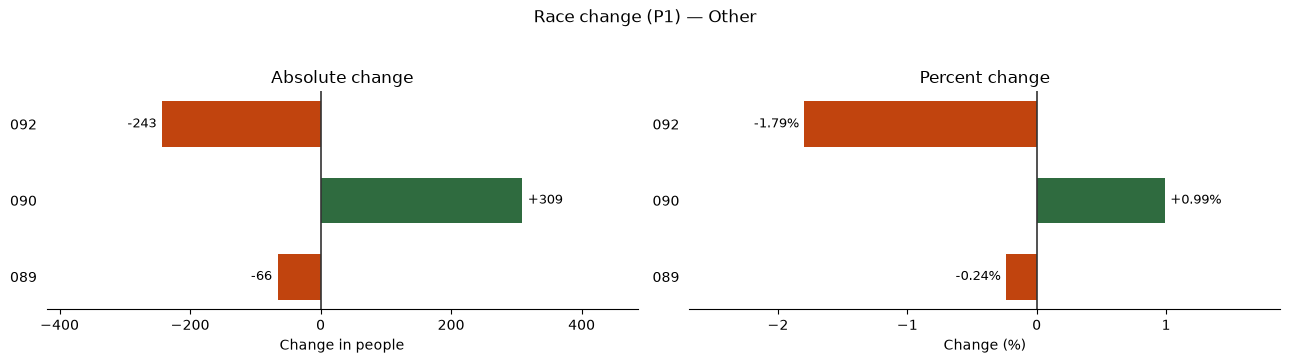

  png  -> output\all_race_p1_change_Two+.png


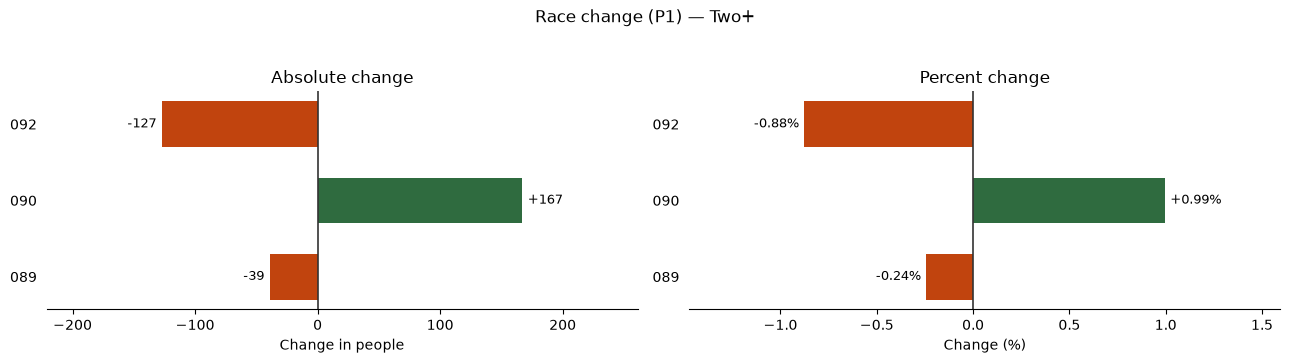


HOUSING
          Total units  Occupied  Vacant
district                               
089             58281     54488    3793
090             54273     51271    3002
092             53552     50975    2577
  csv  -> output\all_housing.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/454ja/visualize  (grouped, 6 series)
  png  -> output\all_housing.png


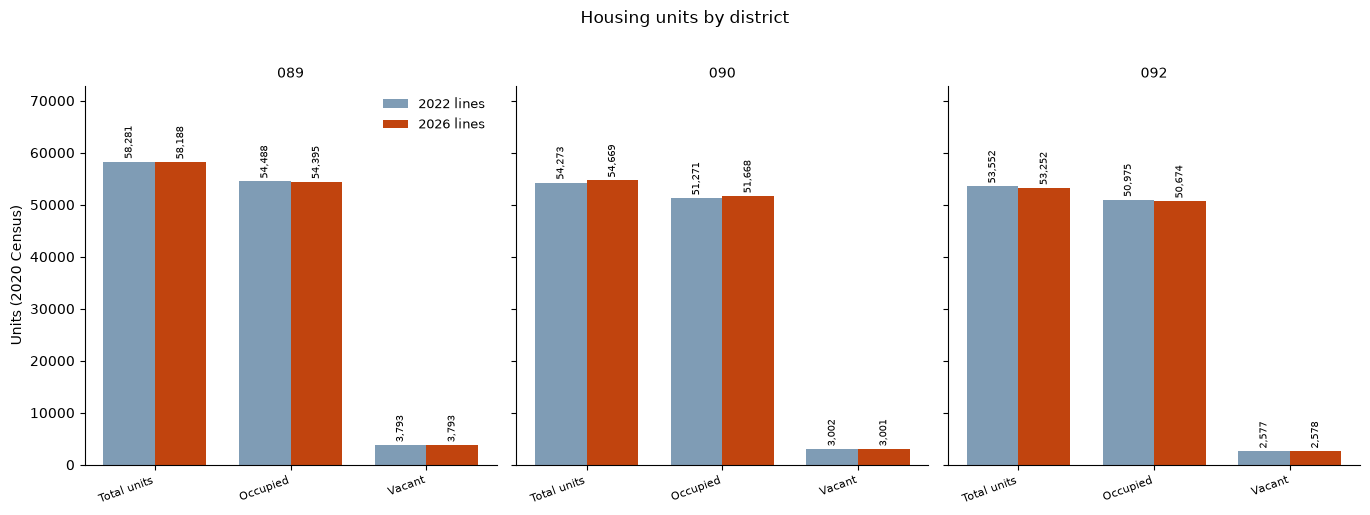

  csv  -> output\all_housing_change.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/yTWpX/visualize  (grouped, 3 series)


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/rlPkl/visualize  (grouped, 3 series)
  png  -> output\all_housing_change_Total_units.png


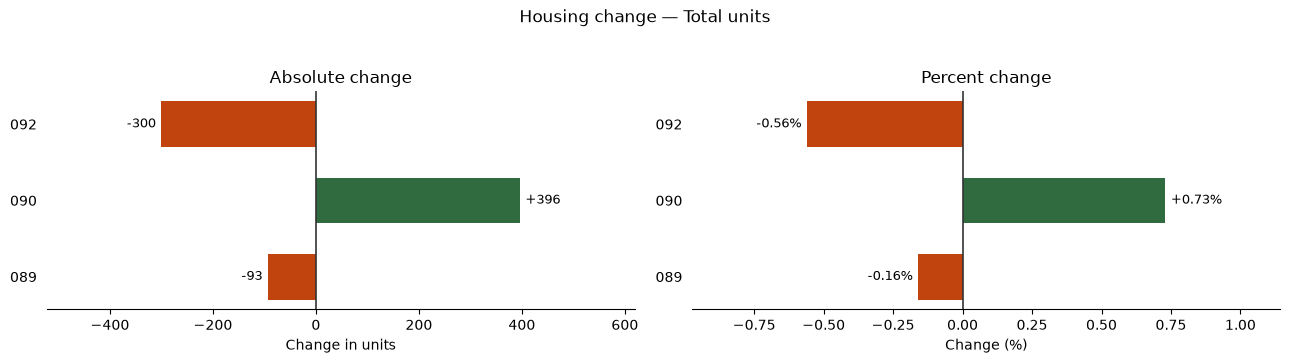

  png  -> output\all_housing_change_Occupied.png


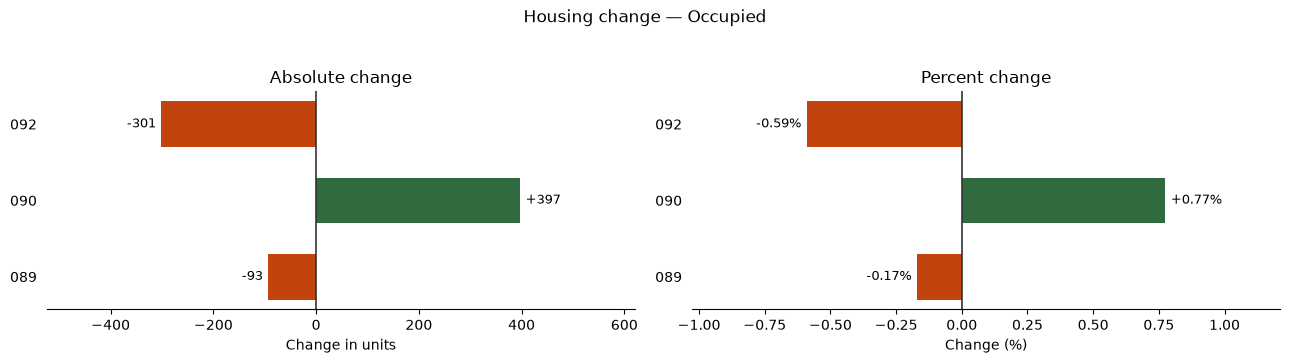

  png  -> output\all_housing_change_Vacant.png


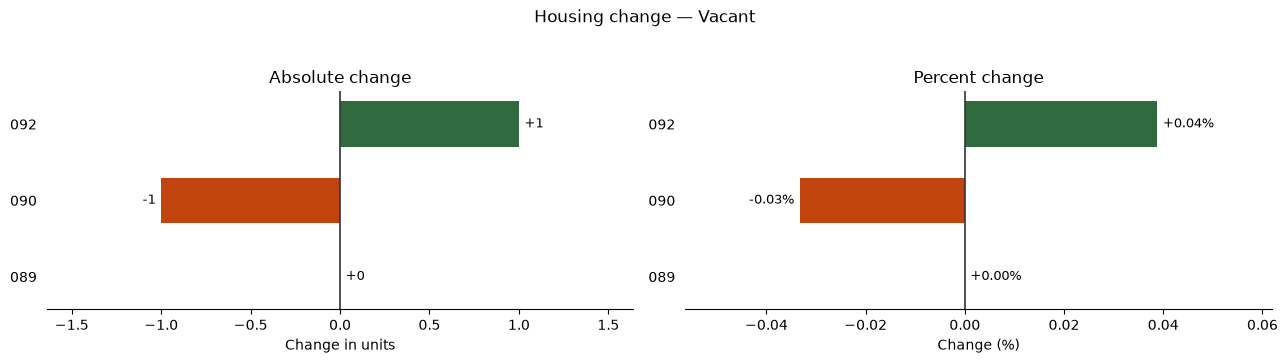


GROUP QUARTERS
          All group quarters  Institutionalized  Noninstitutionalized
district                                                             
089                     1151                590                   561
090                     1905                144                  1761
092                     4964               2084                  2880
  csv  -> output\all_gq.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/ht595/visualize  (grouped, 6 series)
  png  -> output\all_gq.png


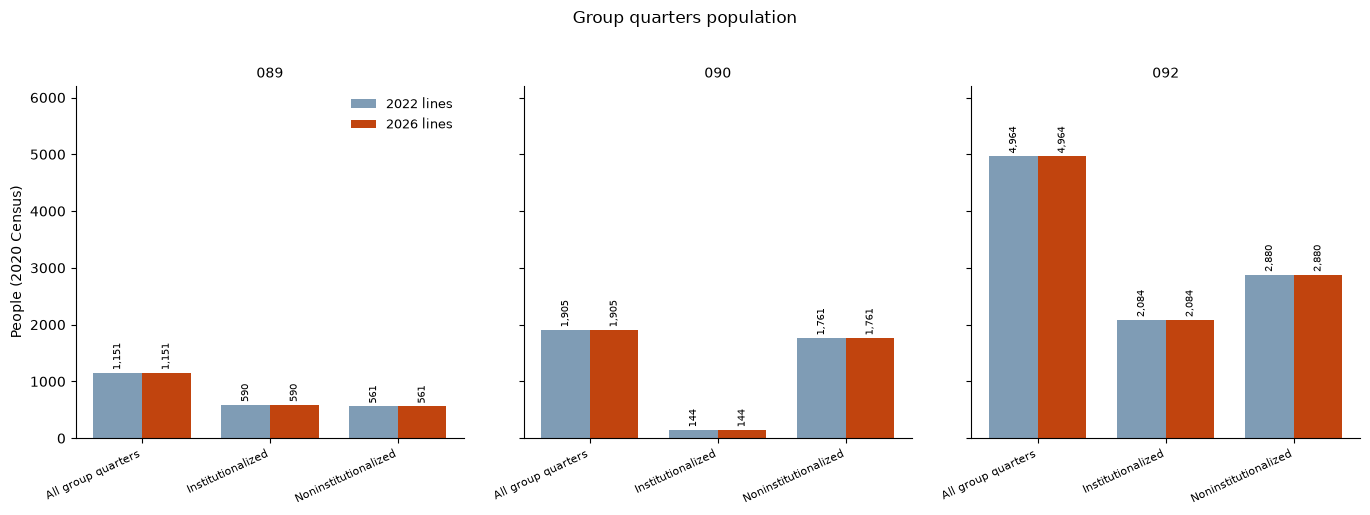

  (no change in group quarters -- change charts skipped)
  (no population in: Military -- not charted)

By facility type:
          Correctional  Juvenile  Nursing  Other institutional  College housing  Other noninstitutional
district                                                                                               
089                  0        37      545                    8                0                     561
090                  0         8      104                   32             1137                     624
092                339       393     1342                   10             1936                     944
  csv  -> output\all_gq_type.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/8JmtC/visualize  (grouped, 12 series)
  png  -> output\all_gq_type.png


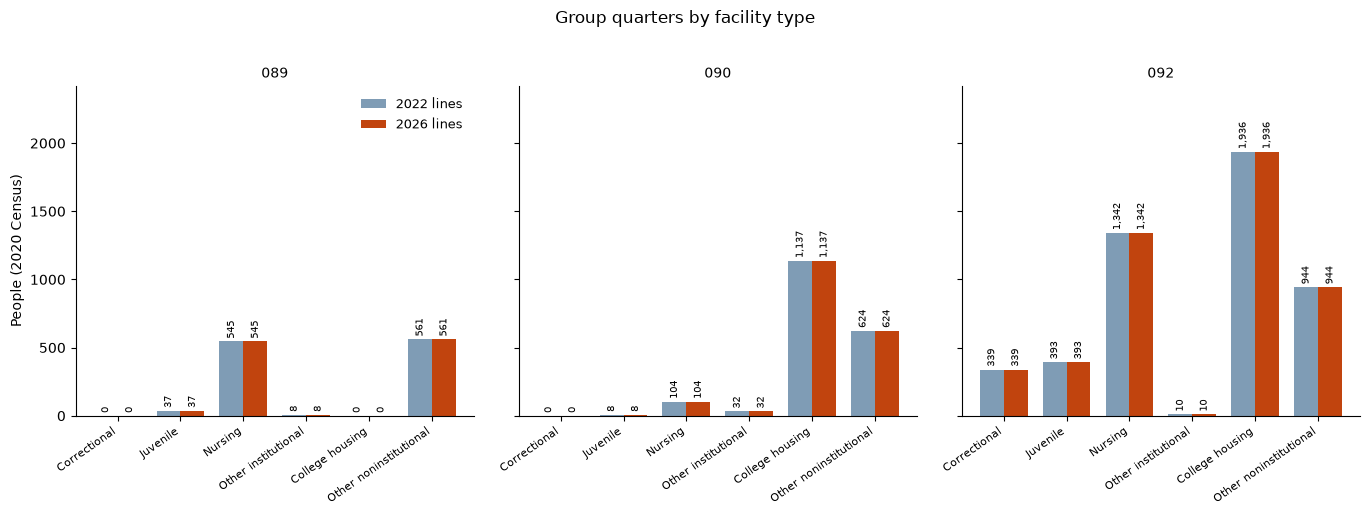

  (no change in group quarters by type -- change charts skipped)


In [13]:
RACE_P1 = {"P1_White(003)": "White", "P1_Black(004)": "Black",
           "P1_AIAN(005)": "AIAN", "P1_Asian(006)": "Asian",
           "P1_NHPI(007)": "NHPI", "P1_Other(008)": "Other",
           "P1_TwoPlus(009)": "Two+"}

RACE_P2 = {"P2_Hispanic(002)": "Hispanic", "P2_NH_White(005)": "NH White",
           "P2_NH_Black(006)": "NH Black", "P2_NH_AIAN(007)": "NH AIAN",
           "P2_NH_Asian(008)": "NH Asian", "P2_NH_NHPI(009)": "NH NHPI",
           "P2_NH_Other(010)": "NH Other", "P2_NH_TwoPlus(011)": "NH Two+"}

HOUSING = {"H1_TotalUnits(001)": "Total units", "H1_Occupied(002)": "Occupied",
           "H1_Vacant(003)": "Vacant"}

# Leaves only -- 002 and 007 are subtotals and would double-count.
GROUP_QUARTERS = {
    "P5_Correctional(003)":  "Correctional",
    "P5_Juvenile(004)":      "Juvenile",
    "P5_Nursing(005)":       "Nursing",
    "P5_OtherInst(006)":     "Other institutional",
    "P5_College(008)":       "College housing",
    "P5_Military(009)":      "Military",
    "P5_OtherNonInst(010)":  "Other noninstitutional",
}

GQ_SUMMARY = {
    "P5_GQTotal(001)": "All group quarters",
    "P5_Inst(002)":    "Institutionalized",
    "P5_NonInst(007)": "Noninstitutionalized",
}


def drop_empty(old, new, chg, pct, label=""):
    """
    Remove measures with nobody in them under either plan.

    A column that is zero everywhere produces a blank panel and a NaN percent
    change (0/0). That is a real finding -- nobody lives in a juvenile facility
    in these districts -- but it belongs in the CSV, not in a chart.

    Returns the four frames with the empty columns removed, or None if every
    column was empty.
    """
    keep = [c for c in old.columns if (old[c].sum() + new[c].sum()) > 0]
    gone = [c for c in old.columns if c not in keep]
    if gone:
        print(f"  (no population in: {', '.join(gone)} -- not charted)")
    if not keep:
        print(f"  (nothing to chart for {label})")
        return None
    return old[keep], new[keep], chg[keep], pct[keep]


def has_change(chg, label=""):
    """True if anything actually moved. An all-zero change chart is blank."""
    if chg.abs().to_numpy().sum() == 0:
        print(f"  (no change in {label} -- change charts skipped)")
        return False
    return True


def run_analysis(data, prefix, area_label=""):
    """
    Population, race (P1 and P2), housing and group quarters, for any
    block-level frame.

    data       : a block-level GeoDataFrame (full study area, or a filtered
                 subset such as one city)
    prefix     : filename prefix for all CSVs and PNGs
    area_label : text appended to every chart title

    Measures that are zero under both plans are dropped before charting;
    change charts are skipped where nothing moved. The full tables are still
    written to CSV either way.
    """
    suffix = f" — {area_label}" if area_label else ""
    results = {}

    # ---------------------------------------------------------- population
    print(f"\n{'=' * 60}\nPOPULATION{suffix}\n{'=' * 60}")
    o_, n_, c_, p_ = summarise(data, {"P1_Total(001)": "Population"})
    print(o_.join(n_, lsuffix=" old", rsuffix=" new").to_string())
    chart_levels(o_, n_, f"Population by district{suffix}",
                 "People (2020 Census)", f"{prefix}_population")
    if has_change(c_, "population"):
        chart_change(c_, p_, f"Population change{suffix}",
                     f"{prefix}_population_change", unit="people")
    results["population"] = (o_, n_, c_, p_)

    # ------------------------------------------------- race, P2 (publish)
    print(f"\n{'=' * 60}\nRACE — P2 (Hispanic separated){suffix}\n{'=' * 60}")
    o2, n2, c2, p2 = summarise(data, RACE_P2)
    results["race_p2"] = (o2, n2, c2, p2)
    print(o2.to_string())
    kept = drop_empty(o2, n2, c2, p2, "race (P2)")
    if kept:
        ko, kn, kc, kp = kept
        chart_levels(ko, kn, f"Race and ethnicity by district{suffix}",
                     "People (2020 Census)", f"{prefix}_race_p2",
                     label_rotation=35)
        if has_change(kc, "race (P2)"):
            chart_change(kc, kp, f"Race change{suffix}",
                         f"{prefix}_race_p2_change", unit="people")
            chart_shares(ko, kn, f"Change in race/ethnicity share{suffix}",
                         f"{prefix}_race_p2_shares")

    # ------------------------------------------ race, P1 (cross-check only)
    print(f"\n{'=' * 60}\nRACE — P1 (race only, Hispanic not separated){suffix}\n{'=' * 60}")
    o1, n1, c1, p1 = summarise(data, RACE_P1)
    results["race_p1"] = (o1, n1, c1, p1)
    print(o1.to_string())
    kept = drop_empty(o1, n1, c1, p1, "race (P1)")
    if kept:
        ko, kn, kc, kp = kept
        # P1 is a cross-check, not the published view -- no Datawrapper push
        # unless DW_SKIP_P1 is turned off in the config cell.
        chart_levels(ko, kn, f"Race by district (P1){suffix}",
                     "People (2020 Census)", f"{prefix}_race_p1",
                     label_rotation=35, dw_skip=DW_SKIP_P1)
        if has_change(kc, "race (P1)"):
            chart_change(kc, kp, f"Race change (P1){suffix}",
                         f"{prefix}_race_p1_change", unit="people",
                         dw_skip=DW_SKIP_P1)

    # ------------------------------------------------------------- housing
    print(f"\n{'=' * 60}\nHOUSING{suffix}\n{'=' * 60}")
    oh, nh, ch, ph = summarise(data, HOUSING)
    results["housing"] = (oh, nh, ch, ph)
    print(oh.to_string())
    kept = drop_empty(oh, nh, ch, ph, "housing")
    if kept:
        ko, kn, kc, kp = kept
        chart_levels(ko, kn, f"Housing units by district{suffix}",
                     "Units (2020 Census)", f"{prefix}_housing",
                     label_rotation=20)
        if has_change(kc, "housing"):
            chart_change(kc, kp, f"Housing change{suffix}",
                         f"{prefix}_housing_change", unit="units")

    # ----------------------------------------------------- group quarters
    print(f"\n{'=' * 60}\nGROUP QUARTERS{suffix}\n{'=' * 60}")
    og, ng, cg, pg = summarise(data, GQ_SUMMARY)
    results["gq_summary"] = (og, ng, cg, pg)
    print(og.to_string())
    kept = drop_empty(og, ng, cg, pg, "group quarters")
    if kept:
        ko, kn, kc, kp = kept
        chart_levels(ko, kn, f"Group quarters population{suffix}",
                     "People (2020 Census)", f"{prefix}_gq", label_rotation=25)
        if has_change(kc, "group quarters"):
            chart_change(kc, kp, f"Group quarters change{suffix}",
                         f"{prefix}_gq_change", unit="people")

    ot, nt, ct, pt = summarise(data, GROUP_QUARTERS)
    results["gq_type"] = (ot, nt, ct, pt)
    kept = drop_empty(ot, nt, ct, pt, "group quarters by type")
    if kept:
        ko, kn, kc, kp = kept
        print("\nBy facility type:")
        print(ko.to_string())
        chart_levels(ko, kn, f"Group quarters by facility type{suffix}",
                     "People (2020 Census)", f"{prefix}_gq_type",
                     label_rotation=35)
        if has_change(kc, "group quarters by type"):
            chart_change(kc, kp, f"Group quarters change by type{suffix}",
                         f"{prefix}_gq_type_change", unit="people")

    return results


results_all = run_analysis(b, "all", "")

**What this does**

Runs the four analyses and writes every table and chart.

P2 comes first because it's the one to publish. P1's "White" includes Hispanic
white residents, so in a heavily Hispanic area it doesn't mean what a reader
assumes. P1 is kept for reference and cross-checking.

Everything sizes itself from the data, so changing `DISTRICTS` in the config cell
is the only edit needed to analyse a different set.

In [14]:
def map_changed_blocks(moved, pop_col="P1_Total(001)",
                       basemap="usa-counties", title=None,
                       save_as="changed_blocks", publish=None):
    """
    Export changed blocks for mapping, and try a Datawrapper symbol map.

    Datawrapper has no census-block basemap, so a true block choropleth needs a
    custom basemap uploaded through the UI. This does two things instead:

      1. Always writes GeoJSON + a lat/lon CSV you can upload by hand.
      2. Attempts a symbol map, one dot per changed block, placed by centroid
         on a built-in basemap.

    basemap : built-in Datawrapper basemap ID. "usa-counties" works nationally;
              search app.datawrapper.de for a tighter one if you want.
    """
    if not len(moved):
        print("  no blocks changed -- nothing to map")
        return None

    # --- always export, so there is a manual path
    cols = ["GEOID", "ad_old", "ad_new", "type", pop_col]
    moved[cols + ["geometry"]].to_file(OUT / f"{save_as}.geojson",
                                       driver="GeoJSON")
    print(f"  geo  -> {OUT / f'{save_as}.geojson'}")

    pts = moved.to_crs(4326).representative_point()
    tbl = moved[cols].copy()
    tbl["latitude"] = pts.y.values
    tbl["longitude"] = pts.x.values
    tbl["moved"] = (tbl["ad_old"].fillna("outside").astype(str) + " to "
                    + tbl["ad_new"].fillna("outside").astype(str))
    tbl = tbl.rename(columns={pop_col: "people"})
    save_csv(tbl, f"{save_as}_points", index=False)

    if not DW_ENABLED:
        return tbl

    title = title or (f"Blocks that changed district — {len(moved)} blocks, "
                      f"{moved[pop_col].sum():,.0f} people")
    publish = DW_PUBLISH if publish is None else publish

    try:
        from datawrapper import Datawrapper
        dwc = Datawrapper(access_token=DW_TOKEN)

        chart = dwc.create_chart(title=title, chart_type="d3-maps-symbols")
        cid = chart["id"] if isinstance(chart, dict) else chart
        dwc.add_data(cid, data=tbl)
        dwc.update_metadata(cid, {
            "axes": {"lat": "latitude", "lon": "longitude",
                     "size": "people", "color": "moved"},
            "visualize": {"basemap": basemap, "size-symbol": "people"},
        })
        url = f"https://app.datawrapper.de/chart/{cid}/visualize"
        print(f"  dw   -> {url}   (symbol map -- set the basemap view in the UI)")
        if publish:
            dwc.publish_chart(cid)
        DW_CHARTS.append({"title": title, "chart_id": cid,
                          "url": url, "published": publish})
        return tbl

    except Exception as e:
        print(f"  dw   -> map FAILED ({type(e).__name__}: {e})")
        print(f"         Upload {save_as}_points.csv to Datawrapper manually:")
        print(f"         new Symbol map -> pick a basemap -> latitude/longitude")
        return tbl


map_changed_blocks(moved)

  geo  -> output\changed_blocks.geojson
  csv  -> output\changed_blocks_points.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\2291414434.py:47: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-maps-symbols")
C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\2291414434.py:49: DeprecationWarning: add_data() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create() or chart.data = df; chart.update()
  dwc.add_data(cid, data=tbl)
This method is deprecated and will be removed in a future version. Use update_chart instead.


  dw   -> https://app.datawrapper.de/chart/jr6vC/visualize   (symbol map -- set the basemap view in the UI)


,GEOID,ad_old,ad_new,type,people,latitude,longitude,moved
16,361190009001012,092,090,between districts,85,40.978161,-73.866306,092 to 090
414,361190009001013,092,090,between districts,0,40.968099,-73.871069,092 to 090
465,361190131022028,092,NaN,left study area,3,41.151776,-73.774567,092 to outside
466,361190131022027,092,NaN,left study area,0,41.152821,-73.774490,092 to outside
670,361190024034008,089,090,between districts,154,40.915669,-73.852027,089 to 090
978,361190107013009,092,NaN,left study area,0,41.009443,-73.829400,092 to outside
1141,361190009001009,092,090,between districts,0,40.971988,-73.868933,092 to 090
1474,361190007022001,090,092,between districts,0,40.963717,-73.891735,090 to 092
1748,361190024034009,089,090,between districts,101,40.915064,-73.852292,089 to 090
1770,361190009003002,092,090,between districts,50,40.979329,-73.867368,092 to 090


## 13. Place-only analysis (optional)

  blocks straddling the Yonkers line: 0
  blocks in Yonkers: 1,616
  population:        211,569

  share of each district inside Yonkers (old plan):
ad_old
089     47.3
090    100.0
092      5.4
  csv  -> output\yonkers_blocks.csv

POPULATION — Yonkers
          Population old  Population new
district                                
089                66312           66057
090               137768          139173
092                 7489            6339
  csv  -> output\yonkers_population.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/xH6Bz/visualize  (grouped, 2 series)
  png  -> output\yonkers_population.png


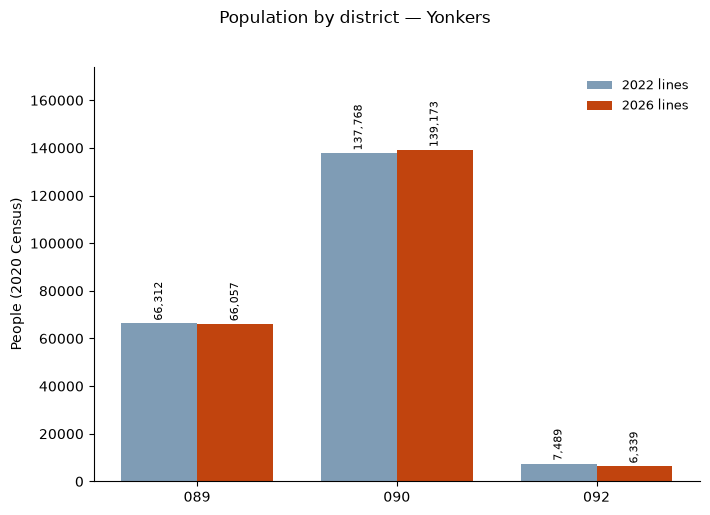

  csv  -> output\yonkers_population_change.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/avkjD/visualize  (grouped, 1 series)


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/izr4V/visualize  (grouped, 1 series)
  png  -> output\yonkers_population_change.png


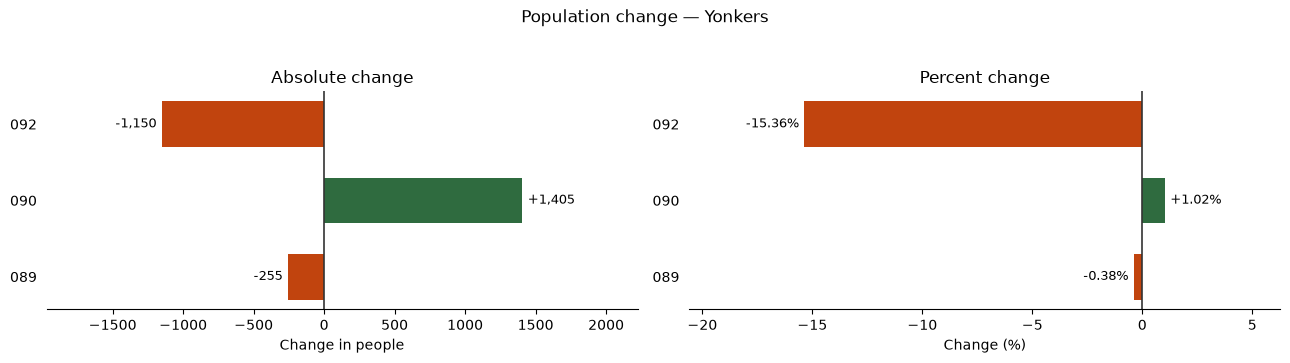


RACE — P2 (Hispanic separated) — Yonkers
          Hispanic  NH White  NH Black  NH AIAN  NH Asian  NH NHPI  NH Other  NH Two+
district                                                                             
089          32520     14178     14427      127      2899       14       630     1517
090          54165     51427     18122      192      9499       18      1140     3205
092           2380      3365       960       11       517        2        63      191
  csv  -> output\yonkers_race_p2.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/z56Ia/visualize  (grouped, 16 series)
  png  -> output\yonkers_race_p2.png


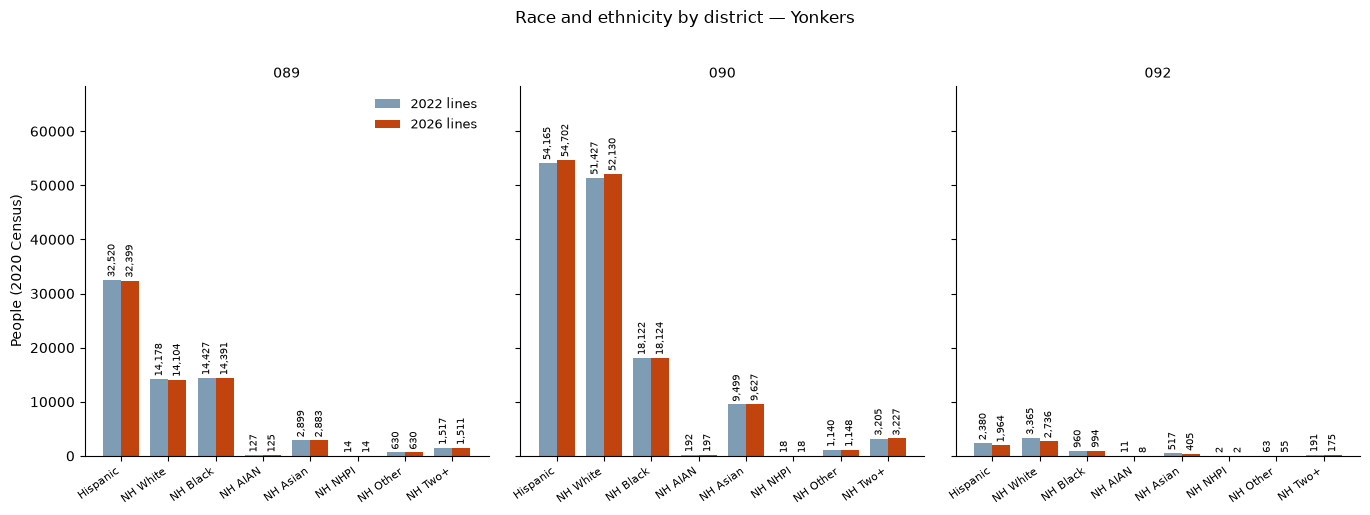

  csv  -> output\yonkers_race_p2_change.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/Fbj3x/visualize  (grouped, 8 series)


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/8GtsY/visualize  (grouped, 8 series)
  png  -> output\yonkers_race_p2_change_Hispanic.png


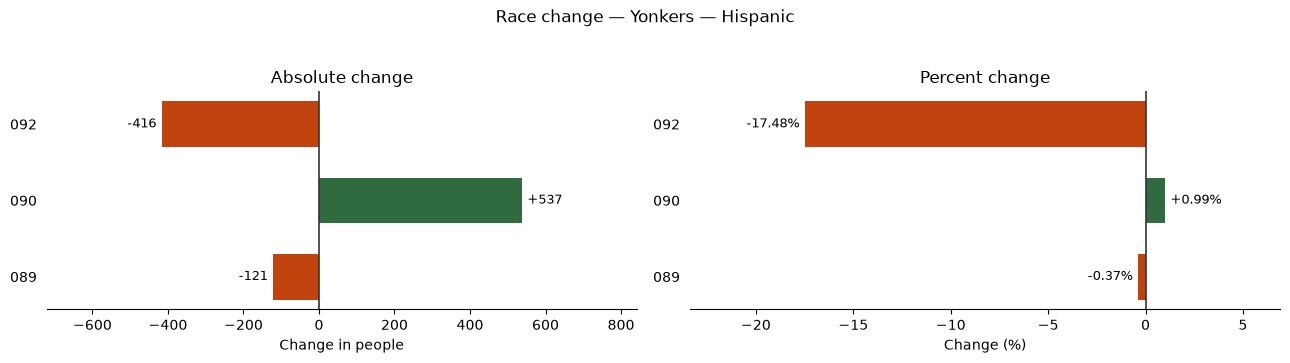

  png  -> output\yonkers_race_p2_change_NH_White.png


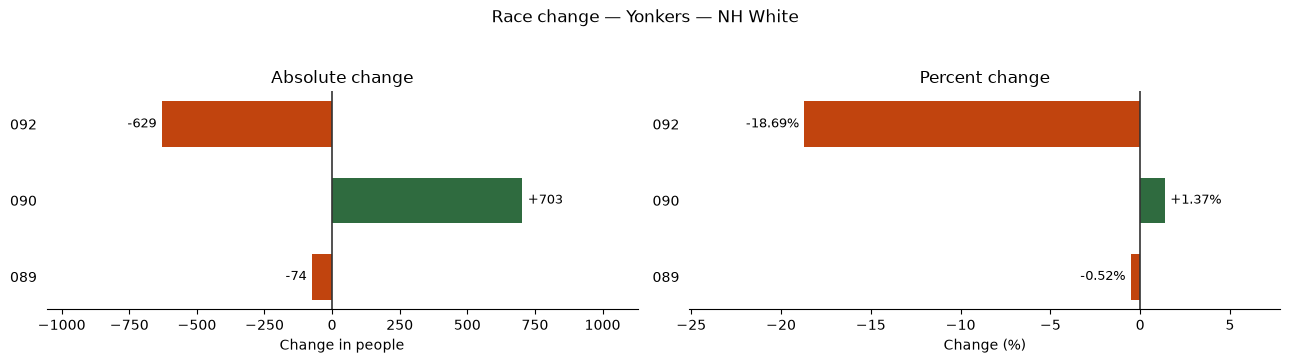

  png  -> output\yonkers_race_p2_change_NH_Black.png


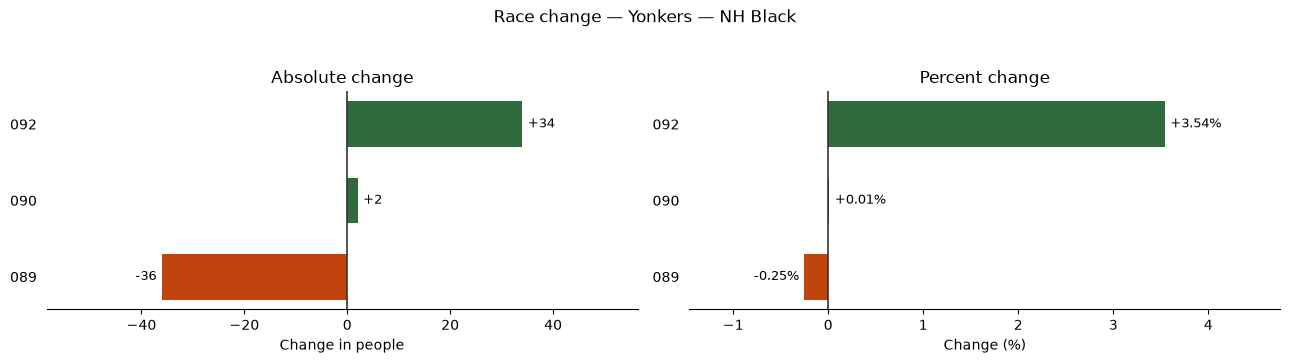

  png  -> output\yonkers_race_p2_change_NH_AIAN.png


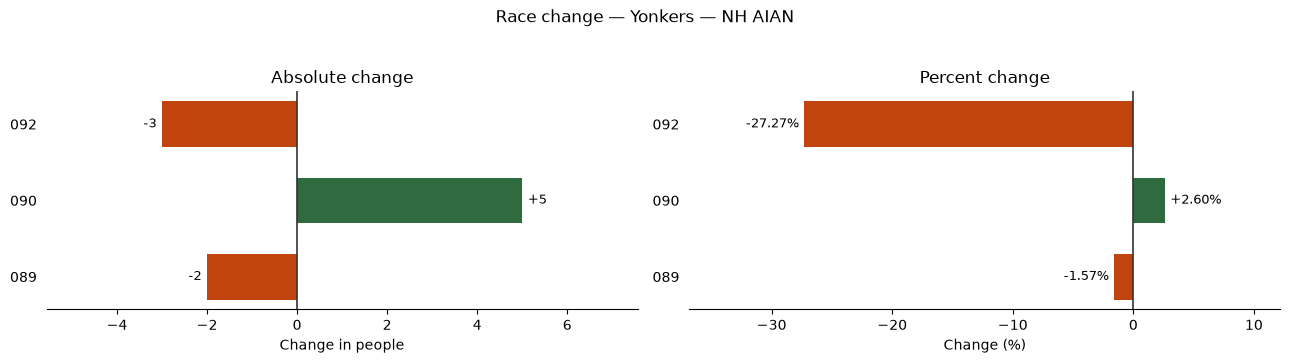

  png  -> output\yonkers_race_p2_change_NH_Asian.png


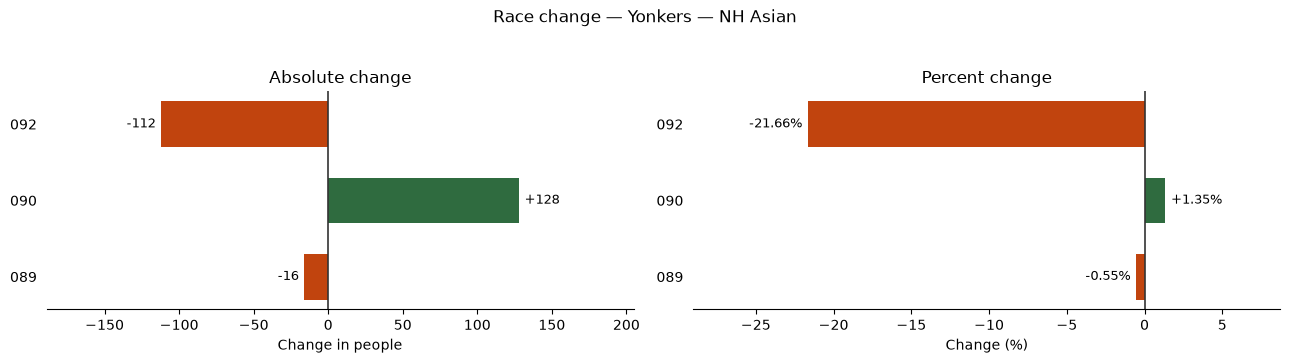

  png  -> output\yonkers_race_p2_change_NH_NHPI.png


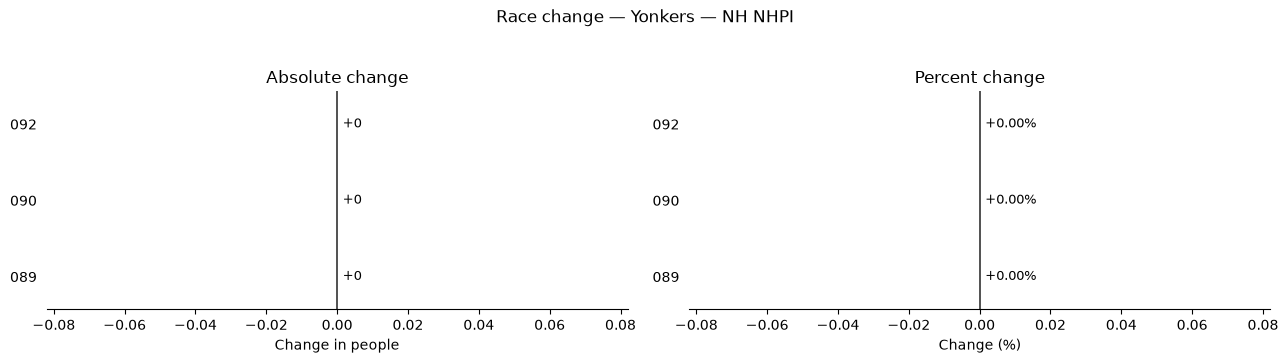

  png  -> output\yonkers_race_p2_change_NH_Other.png


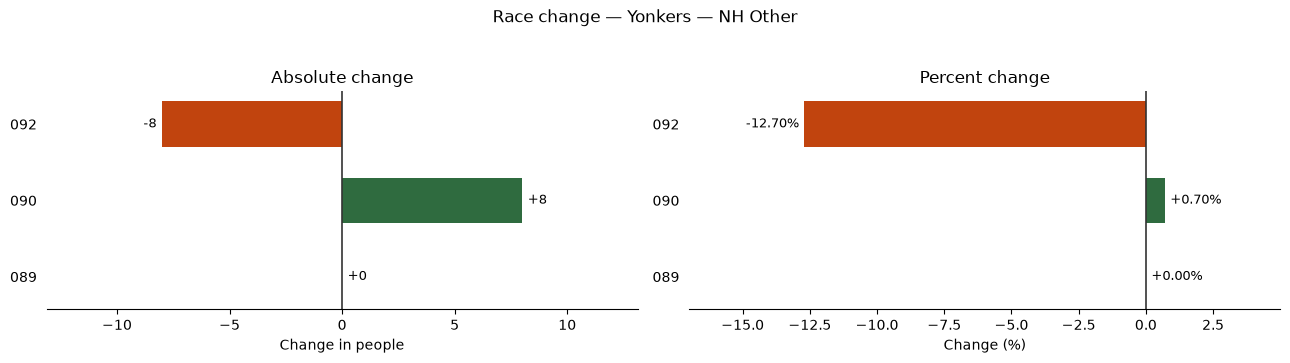

  png  -> output\yonkers_race_p2_change_NH_Two+.png


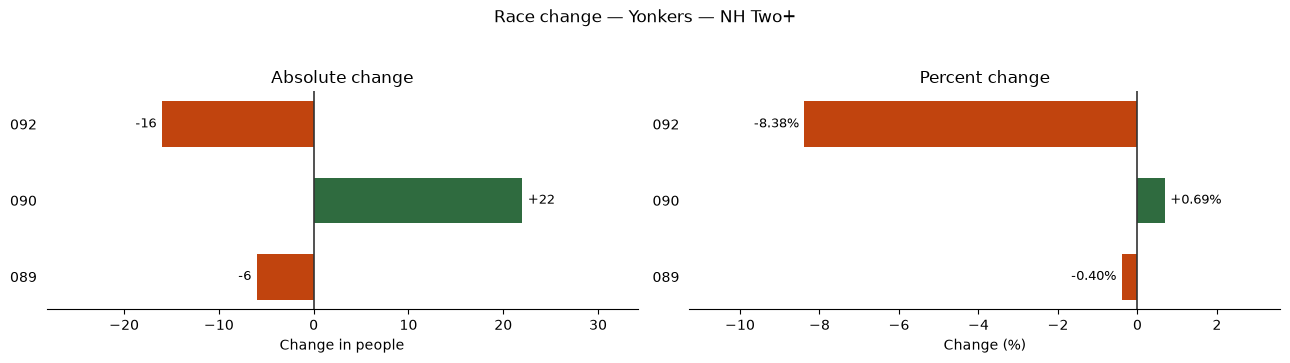

          Hispanic % old  NH White % old  NH Black % old  NH AIAN % old  NH Asian % old  NH NHPI % old  NH Other % old  NH Two+ % old  Hispanic % new  NH White % new  NH Black % new  NH AIAN % new  NH Asian % new  NH NHPI % new  NH Other % new  NH Two+ % new  Hispanic pp change  NH White pp change  NH Black pp change  NH AIAN pp change  NH Asian pp change  NH NHPI pp change  NH Other pp change  NH Two+ pp change
district                                                                                                                                                                                                                                                                                                                                                                                                                       
089                49.04           21.38           21.76           0.19            4.37           0.02            0.95           2.29           49.05           21.35   

C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/1xYxq/visualize  (grouped, 8 series)
  png  -> output\yonkers_race_p2_shares.png


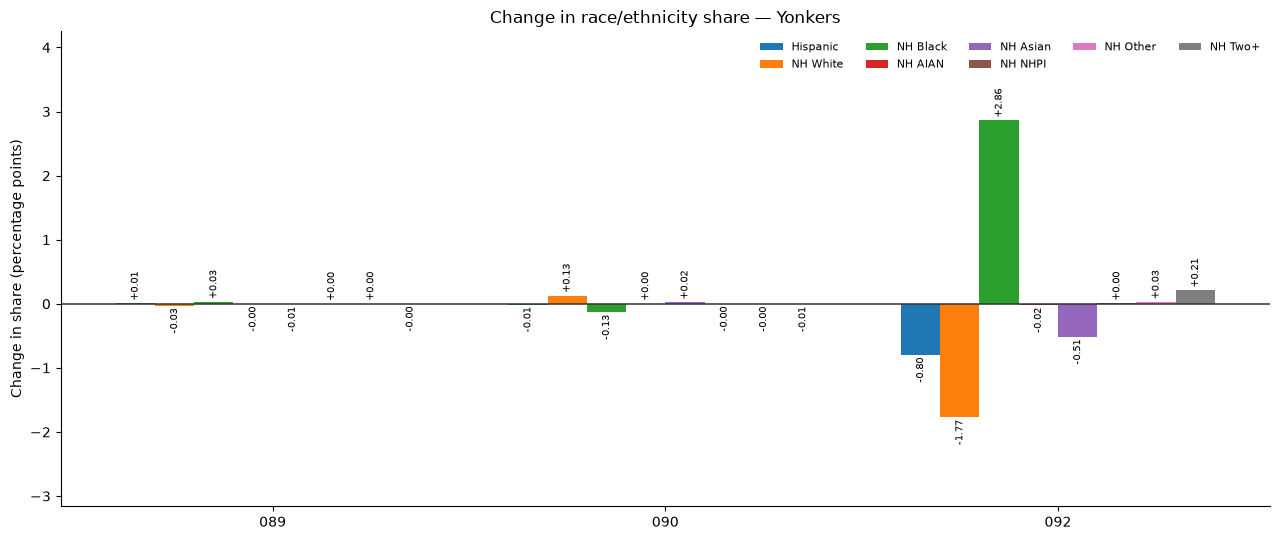


RACE — P1 (race only, Hispanic not separated) — Yonkers
          White  Black  AIAN  Asian  NHPI  Other   Two+
district                                               
089       17361  16335   977   2975    43  19620   9001
090       57791  20695  1559   9666    48  31224  16785
092        3664   1077    52    521     2   1240    933
  csv  -> output\yonkers_race_p1.csv
  png  -> output\yonkers_race_p1.png


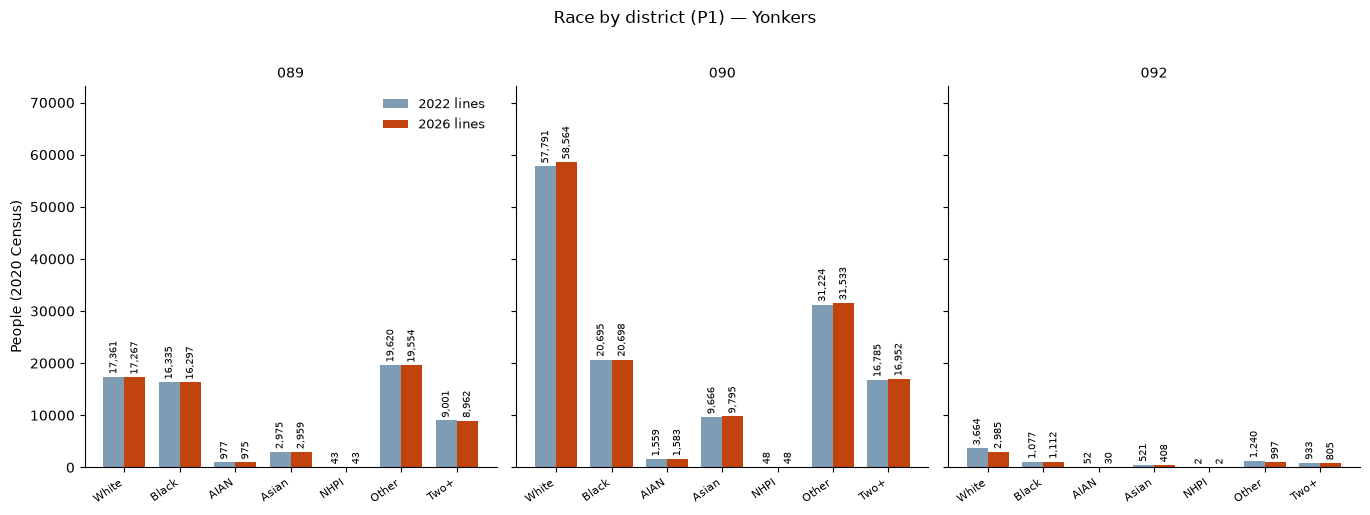

  csv  -> output\yonkers_race_p1_change.csv
  png  -> output\yonkers_race_p1_change_White.png


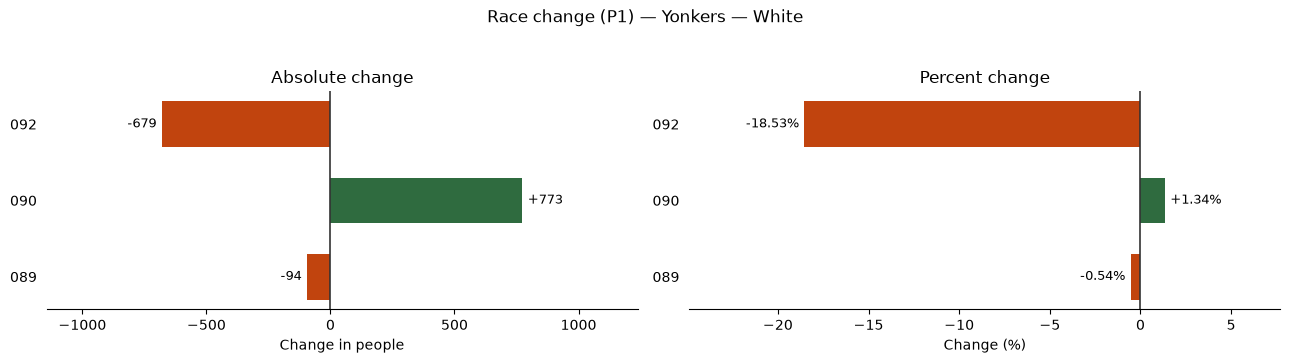

  png  -> output\yonkers_race_p1_change_Black.png


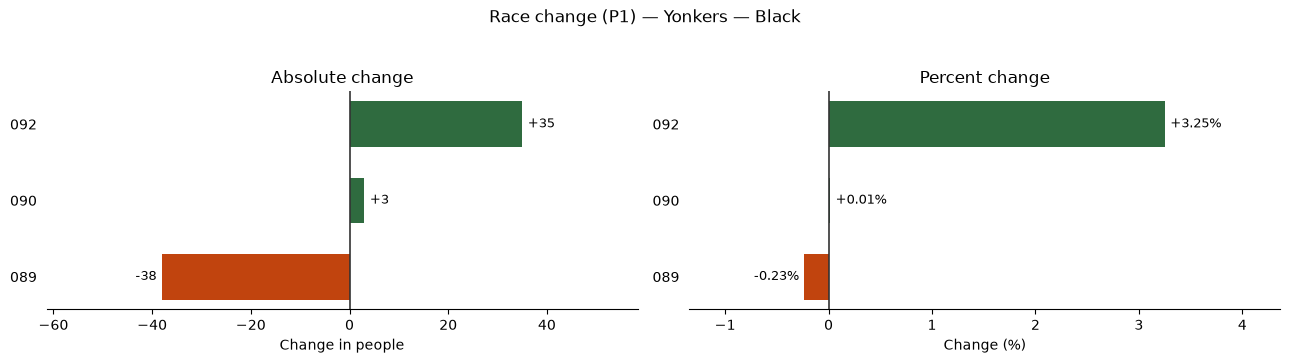

  png  -> output\yonkers_race_p1_change_AIAN.png


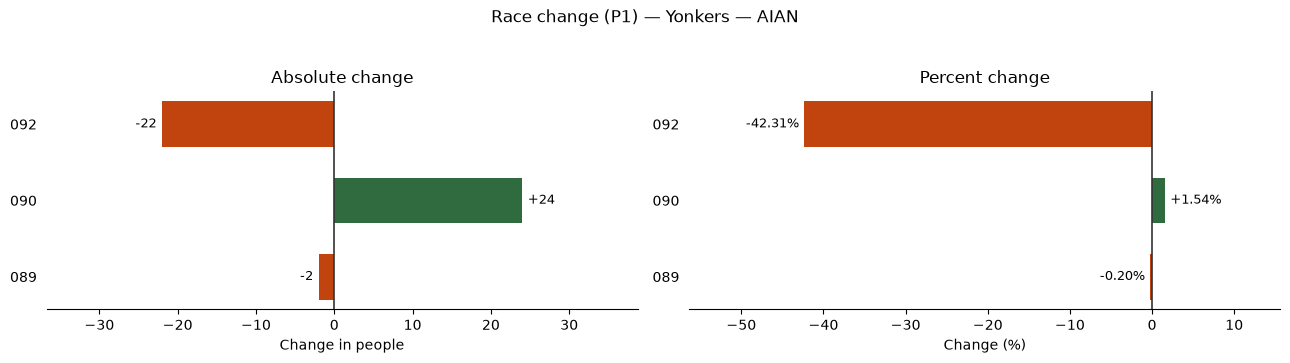

  png  -> output\yonkers_race_p1_change_Asian.png


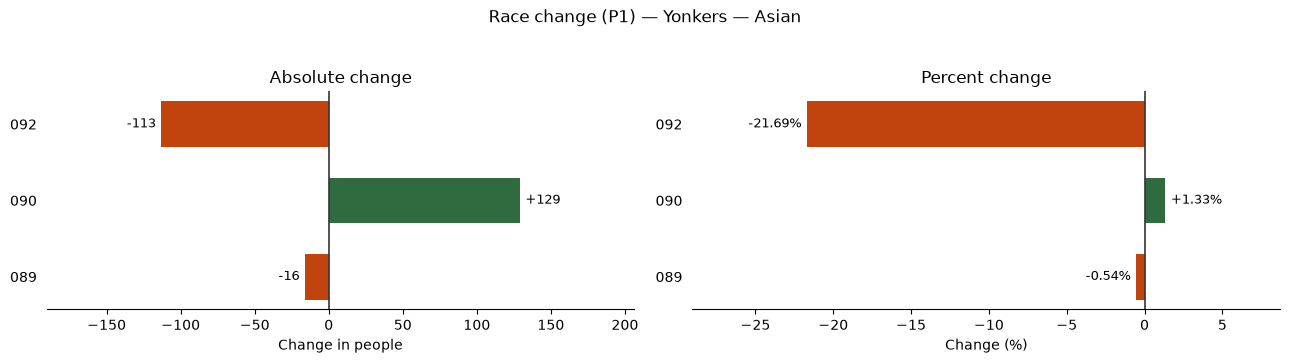

  png  -> output\yonkers_race_p1_change_NHPI.png


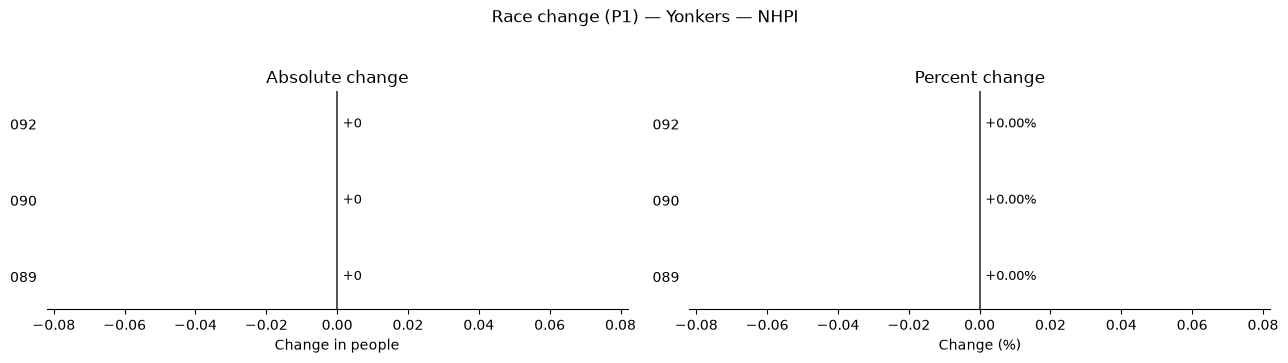

  png  -> output\yonkers_race_p1_change_Other.png


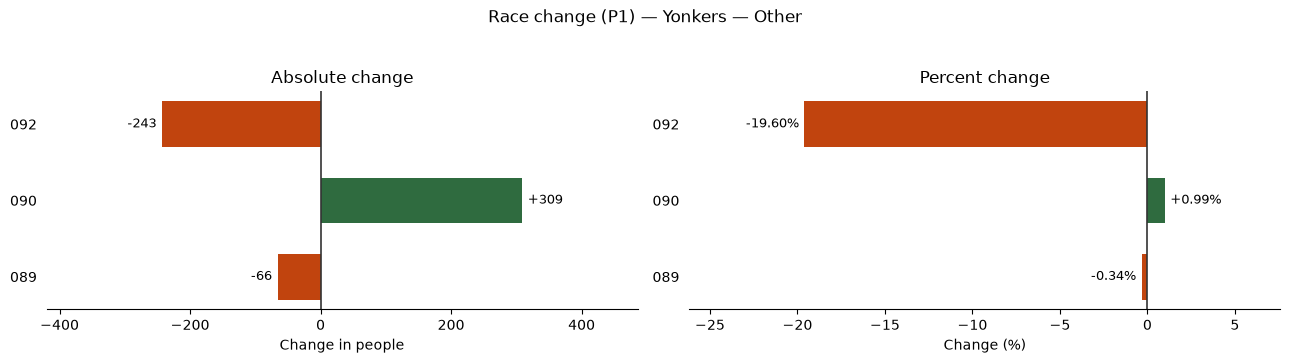

  png  -> output\yonkers_race_p1_change_Two+.png


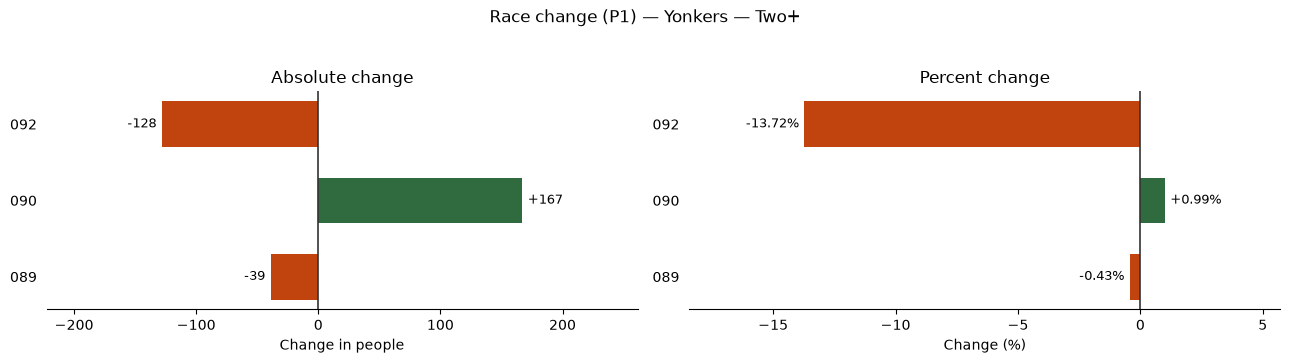


HOUSING — Yonkers
          Total units  Occupied  Vacant
district                               
089             27931     26202    1729
090             54273     51271    3002
092              3324      3075     249
  csv  -> output\yonkers_housing.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/tp1bY/visualize  (grouped, 6 series)
  png  -> output\yonkers_housing.png


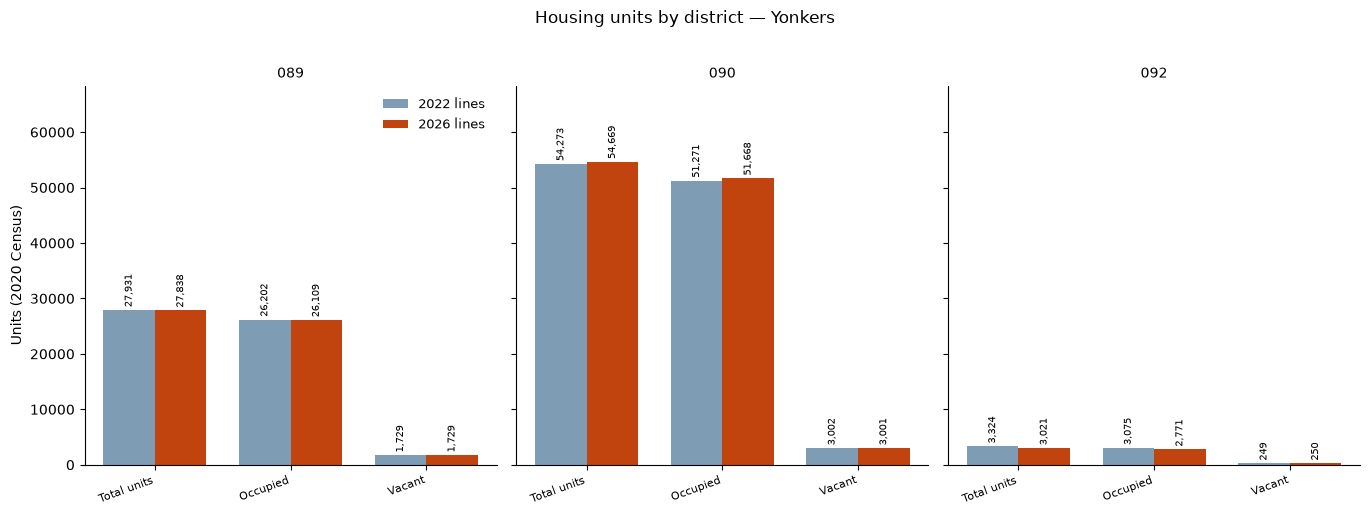

  csv  -> output\yonkers_housing_change.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/LYPxU/visualize  (grouped, 3 series)


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/PNnQT/visualize  (grouped, 3 series)
  png  -> output\yonkers_housing_change_Total_units.png


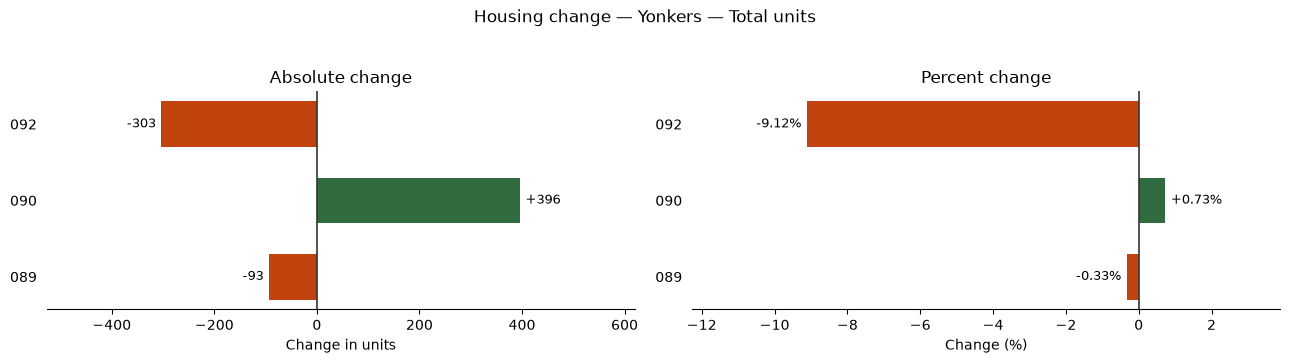

  png  -> output\yonkers_housing_change_Occupied.png


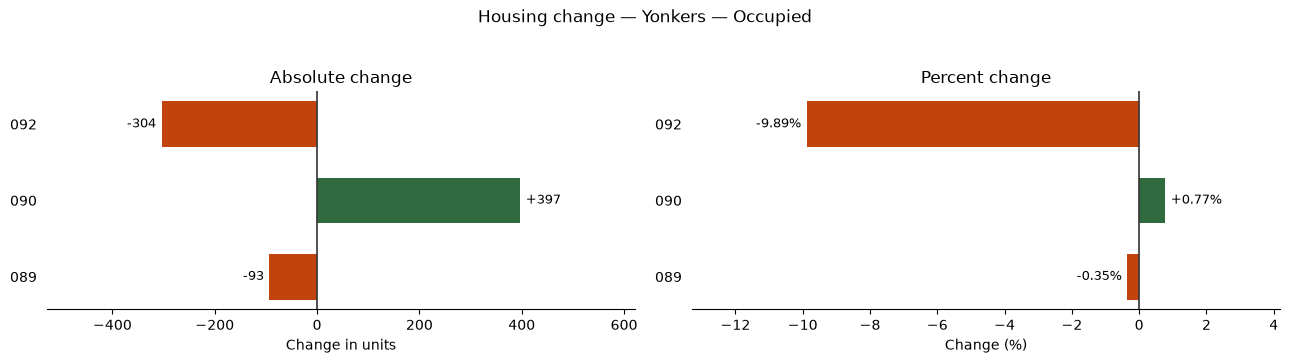

  png  -> output\yonkers_housing_change_Vacant.png


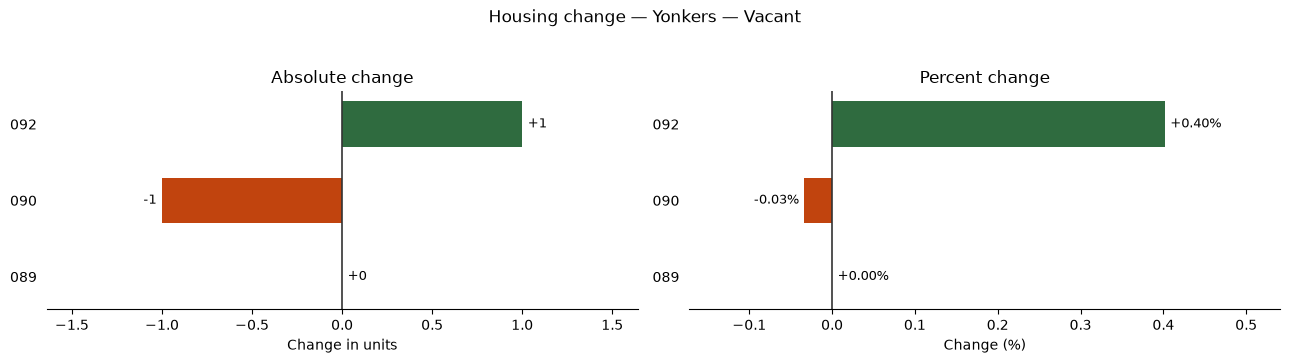


GROUP QUARTERS — Yonkers
          All group quarters  Institutionalized  Noninstitutionalized
district                                                             
089                      655                350                   305
090                     1905                144                  1761
092                      374                256                   118
  csv  -> output\yonkers_gq.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/4fjRr/visualize  (grouped, 6 series)
  png  -> output\yonkers_gq.png


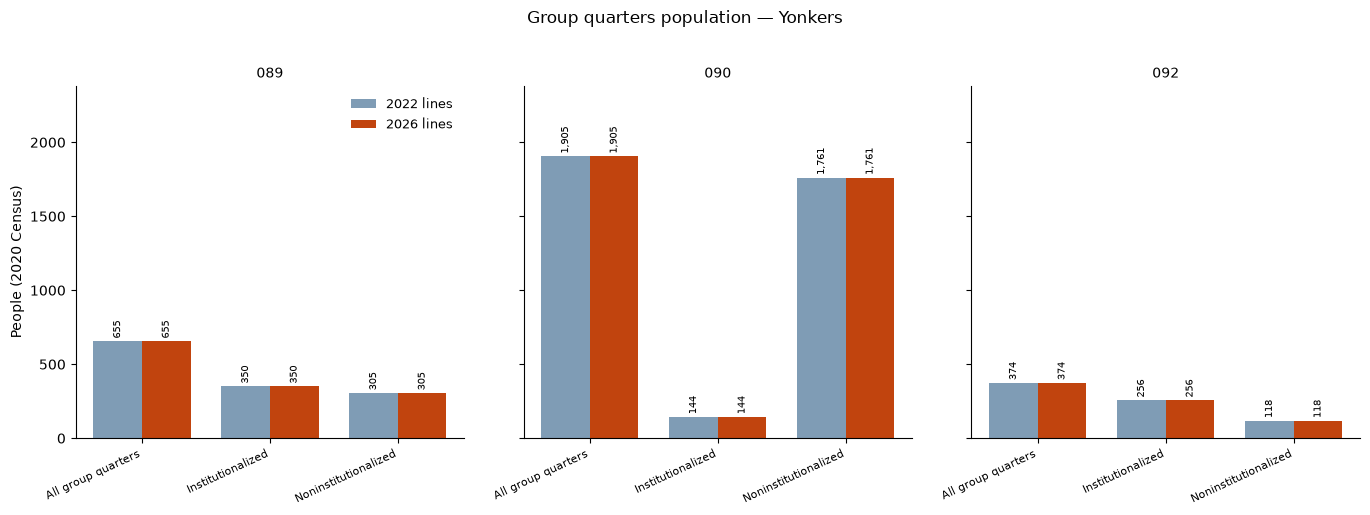

  (no change in group quarters -- change charts skipped)
  (no population in: Correctional, Military -- not charted)

By facility type:
          Juvenile  Nursing  Other institutional  College housing  Other noninstitutional
district                                                                                 
089             21      321                    8                0                     305
090              8      104                   32             1137                     624
092              0      256                    0                0                     118
  csv  -> output\yonkers_gq_type.csv


C:\Users\Atharv\AppData\Local\Temp\ipykernel_1948\3403309973.py:132: DeprecationWarning: create_chart() is deprecated for chart types with object-oriented classes. For maps, tables and other unsupported visualization types it remains a supported compatibility path until a dedicated class is available. Example for supported charts: chart = BarChart(title='My Chart', data=df).create()
  chart = dwc.create_chart(title=title, chart_type="d3-bars-grouped",


  dw   -> https://app.datawrapper.de/chart/nEysI/visualize  (grouped, 10 series)
  png  -> output\yonkers_gq_type.png


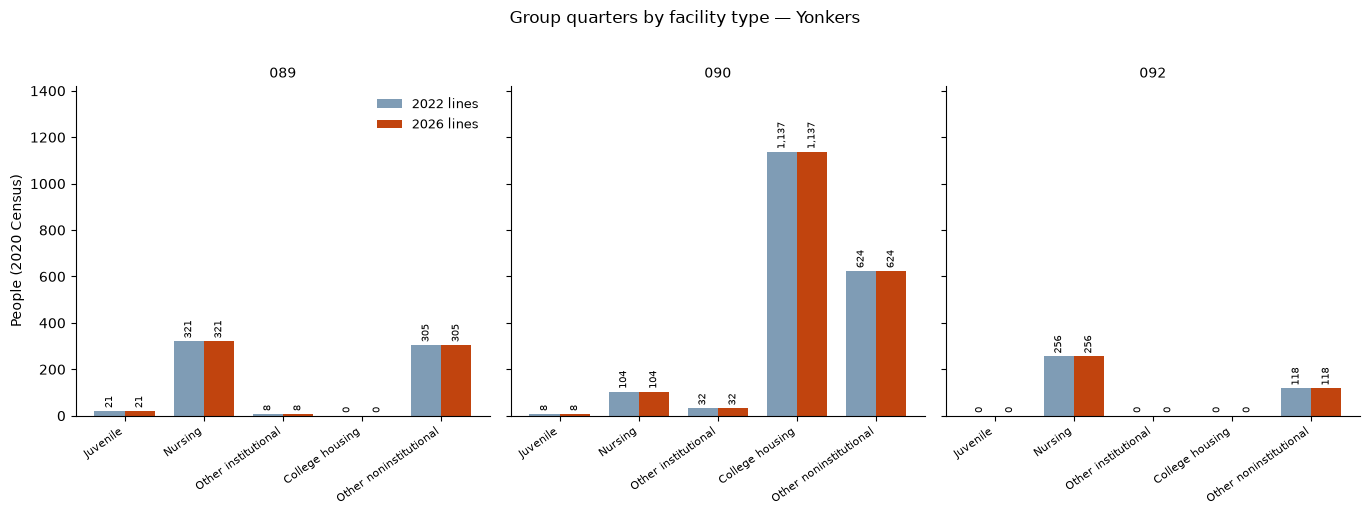

  (no change in group quarters by type -- change charts skipped)


In [15]:
def filter_to_place(b, boundary, name=BOUNDARY_NAME, threshold=0.5,
                    save_as=None):
    """
    Keep blocks that are mostly inside a place boundary.

    Census blocks are built to nest inside incorporated places, so in practice
    almost no block straddles a city line -- but this measures it rather than
    assuming, and reports any that do.

    threshold : minimum share of a block's area inside the place (0.5 = majority)
    """
    bb = b[["GEOID", "geometry"]].to_crs(AREA_CRS)
    bb["area"] = bb.geometry.area

    parts = gpd.overlay(bb, boundary[["geometry"]].to_crs(AREA_CRS),
                        how="intersection", keep_geom_type=False)
    parts = parts[parts.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    parts["share"] = parts.geometry.area / parts["area"]

    b = b.copy()
    b["place_share"] = b["GEOID"].map(parts.set_index("GEOID")["share"]).fillna(0.0)

    straddle = b[(b["place_share"] > 0.005) & (b["place_share"] < 0.995)]
    print(f"  blocks straddling the {name} line: {len(straddle)}"
          + (f"  ({straddle['P1_Total(001)'].sum():,.0f} people)" if len(straddle) else ""))

    sub = b[b["place_share"] >= threshold].reset_index(drop=True)
    print(f"  blocks in {name}: {len(sub):,}")
    print(f"  population:        {sub['P1_Total(001)'].sum():,.0f}")
    print(f"\n  share of each district inside {name} (old plan):")
    pct = b.groupby("ad_old").apply(
        lambda g: g.loc[g["place_share"] >= threshold, "P1_Total(001)"].sum()
        / g["P1_Total(001)"].sum() * 100, include_groups=False).round(1)
    print(pct.to_string())

    if save_as:
        save_csv(sub.drop(columns="geometry"), save_as, index=False)
    return sub


if boundary is not None:
    place_b = filter_to_place(b, boundary, save_as=f"{BOUNDARY_NAME.lower()}_blocks")
    results_place = run_analysis(place_b, BOUNDARY_NAME.lower(), BOUNDARY_NAME)
else:
    print("BOUNDARY_GEOID is None -- skipping place-only analysis.")

**What this does**

Reruns the same four analyses on just the blocks inside the configured place.

The straddle count is the honesty check. District lines are guaranteed to follow
block edges because districts are built from blocks; a city line has no such
guarantee. In practice the Census builds blocks to nest inside incorporated
places too, so this usually reports zero — but it reports the number rather than
assuming.

The per-district share is worth reading: a district that is only 5% inside the
city will swing wildly in percent terms on a small base.

---

## What was produced

Everything is in `output/`. Per analysis area (`all_`, and the place prefix if
configured):

| File | Contents |
|---|---|
| `*_population.csv` / `.png` | Population per district, both plans |
| `*_population_change.*` | Absolute and percent change |
| `*_race_p2.*` | Hispanic + non-Hispanic race breakdown — **use this one** |
| `*_race_p2_shares.csv` | Composition shares and percentage-point change |
| `*_race_p1.*` | Race ignoring Hispanic origin, for reference |
| `*_housing.*` | Total, occupied and vacant units |
| `district_area_change.csv` | Land-area change per district |
| `counties_touched.csv` | Counties overlapping either plan |
| `blocks_changed_summary.csv` | Blocks and people that moved, by type |
| `blocks_changed_flow.csv` | Old district × new district population flow |
| `reconciliation.csv` | Proof every person traces to a moved block |
| `blocks_assigned.csv` / `.gpkg` | The full block-level dataset |

## Notes for a writeup

**These are counts, not estimates.** 2020 Decennial PL 94-171 is a complete
count, and blocks nest inside districts, so district totals carry no margin of
error and no modelling. Say so — it's a stronger claim than survey data supports.

**Percentage points, not percent.** Every `pp change` column is a difference
between two shares.

**Cite the enacting body, not TIGERweb.** The Census serves the boundaries; the
state enacted them. For New York that is LATFOR (`latfor.state.ny.us/maps/`).

**Record the vintages.** TIGERweb's `Current` service advances each year, so note
which services and LSY values you used and the date you ran this.

## 14. Datawrapper index

In [16]:
if DW_CHARTS:
    idx = pd.DataFrame(DW_CHARTS)
    print(f"{len(idx)} Datawrapper charts created "
          f"({'published' if DW_PUBLISH else 'drafts'}):\n")
    print(idx[["title", "url"]].to_string(index=False))
    save_csv(idx, "datawrapper_charts", index=False)
elif DW_ENABLED:
    print("Datawrapper is ON but no charts were created -- check errors above.")
else:
    print("Datawrapper is OFF. Every chart's data is still in output/*.csv "
          "and can be uploaded by hand.")

25 Datawrapper charts created (drafts):

                                                 title                                              url
                                Population by district https://app.datawrapper.de/chart/jEtrR/visualize
                          Population change — absolute https://app.datawrapper.de/chart/WSfms/visualize
                           Population change — percent https://app.datawrapper.de/chart/l44zk/visualize
                        Race and ethnicity by district https://app.datawrapper.de/chart/zRBwC/visualize
                                Race change — absolute https://app.datawrapper.de/chart/gZQYZ/visualize
                                 Race change — percent https://app.datawrapper.de/chart/hdT5x/visualize
                        Change in race/ethnicity share https://app.datawrapper.de/chart/ftKod/visualize
                             Housing units by district https://app.datawrapper.de/chart/454ja/visualize
                       

**What this does**

Writes `datawrapper_charts.csv` — every chart title, its ID and its edit URL.

Worth keeping: a full run creates around 40 charts, and finding a specific one in
the Datawrapper dashboard without an index is tedious. This CSV is also what you
would send Stella so she can open them directly.

If Datawrapper is off, every chart's data still sits in `output/` as CSV and can
be uploaded by hand.